# TODO

In [3]:
## TODO: add visibility example

## TODO:check if there is an image for sample and count the available pixel

## TODO: count by category to evaluate and correctly interprete. for example at 20 samples

## derive object speed

## TODO: may be rename ann_df?

## TODO: for complex code writhe the conceptual algo in plain text


# MY NOTES

**NOTE:**
* Moving attributes: radar can help
* Categories: is imbalanced


* ann_df from annotation table
* ead_df = ann_df + features

# Objective and setup
The detection task considered in this project is 3D object detection on nuScenes, with a focus on understanding the role of sensor fusion. For each scene, the model must detect relevant traffic participants and estimate their class, 3D location, size, and orientation. Because nuScenes provides multiple sensing modalities, the task is not only to predict objects accurately, but also to understand how LiDAR, cameras, and radar contribute differently to perception. LiDAR provides strong geometric and localization cues, cameras provide semantic and appearance information, and radar may support motion-aware reasoning. The EDA is therefore designed to study detection difficulty across classes, distances, visibility levels, and scene conditions, and to identify where fusion is likely to provide real benefit over unimodal baselines.

**The goal**: the model must place the **right 3D box** around each relevant object around the ego vehicle.

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import sys
import seaborn as sns

from IPython.display import display
from typing import Dict, List, Optional, Any, Tuple # required for python 3.8
from pprint import pprint
from pathlib import Path
from tqdm.auto import tqdm

# logging.basicConfig(level=logging.INFO, format="%(message)s")
# # logging.basicConfig(level=logging.DEBUG, format="%(message)s")
# logger = logging.getLogger("notebook")

pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)

print(sys.version)

3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 4090


## Load the dataset

In [4]:
import os
from nuscenes.nuscenes import NuScenes

# Select local or ubelix environment
RUNNING_ON = "ubelix"   # "local" or "ubelix"
DATASET = "full"        # "mini" or "full"

# Set dataset path and version
if RUNNING_ON == "local":
    if DATASET == "mini":
        DATAROOT = "../data/sets/nuscenes"
        VERSION = "v1.0-mini"
    elif DATASET == "full":
        DATAROOT = "../data/sets/nuscenes_full"
        VERSION = "v1.0-trainval"
    else:
        raise ValueError("DATASET must be 'mini' or 'full'")

elif RUNNING_ON == "ubelix":
    if DATASET == "mini":
        DATAROOT = "/storage/homefs/ae04q066/datasets/nuscenes_mini"
        VERSION = "v1.0-mini"
    elif DATASET == "full":
        DATAROOT = "/rs_scratch/users/ae04q066/nuscenes_full"
        VERSION = "v1.0-trainval"
    else:
        raise ValueError("DATASET must be 'mini' or 'full'")

else:
    raise ValueError("RUNNING_ON must be 'local' or 'ubelix'")

# Check path
assert os.path.isdir(DATAROOT), f"DATAROOT not found: {os.path.abspath(DATAROOT)}"

print("DATAROOT:", DATAROOT)
print("VERSION:", VERSION)

# Load nuScenes
nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=True)

DATAROOT: /rs_scratch/users/ae04q066/nuscenes_full
VERSION: v1.0-trainval
Loading NuScenes tables for version v1.0-trainval...


23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 26.551 seconds.
Reverse indexing ...
Done reverse indexing in 6.4 seconds.


In [6]:
# from nuscenes.nuscenes import NuScenes

# DATAROOT: str= "../data/sets/nuscenes"
# VERSION: str = "v1.0-mini"

# assert os.path.isdir(DATAROOT), f"DATAROOT not found: {os.path.abspath(DATAROOT)}"

# # Load the nuScenes tables. 
# nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=True)

# nuScenes dataset

## Database schema

**Source:** The following text and schema image were copied from the official nuScenes tutorial page https://github.com/nutonomy/nuscenes-devkit/blob/master/python-sdk/tutorials/nuscenes_tutorial.ipynb

1. `log` - Log information from which the data was extracted.
2. `scene` - 20 second snippet of a car's journey.
3. `sample` - An annotated snapshot of a scene at a particular timestamp.
4. `sample_data` - Data collected from a particular sensor.
5. `ego_pose` - Ego vehicle poses at a particular timestamp.
6. `sensor` - A specific sensor type.
7. `calibrated sensor` - Definition of a particular sensor as calibrated on a particular vehicle.
8. `instance` - Enumeration of all object instance we observed.
9. `category` - Taxonomy of object categories (e.g. vehicle, human).
10. `attribute` - Property of an instance that can change while the category remains the same.
11. `visibility` - Fraction of pixels visible in all the images collected from 6 different cameras.
12. `sample_annotation` - An annotated instance of an object within our interest.
13. `map` - Map data that is stored as binary semantic masks from a top-down view.

The database schema is visualized below. For more information see the [nuScenes schema](https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/schema_nuscenes.md) page.
![](https://www.nuscenes.org/public/images/nuscenes-schema.svg)

In [5]:
# Dataset version (e.g., "v1.0-mini" = development subset)
print("version:", nusc.version)

# Number of logs (recording sessions collected by the ego vehicle)
print("number of logs:", len(nusc.log))

# Number of scenes (~20s segments extracted from logs)
print("number of scenes:", len(nusc.scene))

# List of available tables (nuScenes is organized as a relational-style database)
print("List of tables:", nusc.table_names)


version: v1.0-trainval
number of logs: 68
number of scenes: 850
List of tables: ['category', 'attribute', 'visibility', 'instance', 'sensor', 'calibrated_sensor', 'ego_pose', 'log', 'scene', 'sample', 'sample_data', 'sample_annotation', 'map']


In [6]:
print("=== Scenes ===")
nusc.list_scenes()

print("\n=== Categories ===")
nusc.list_categories()

print("\n=== Attributes ===")
nusc.list_attributes()

=== Scenes ===
scene-0161, Car overtaking, parking lot, peds, ped ... [18-05-21 15:07:23]   19s, boston-seaport, #anns:1970
scene-0162, Leaving parking lot, parked cars, hidde... [18-05-21 15:07:43]   19s, boston-seaport, #anns:2230
scene-0163, Drive along street with dozens of parke... [18-05-21 15:08:03]   19s, boston-seaport, #anns:1585
scene-0164, Turn into narrow street, parked cars, p... [18-05-21 15:08:38]   19s, boston-seaport, #anns:745
scene-0165, Pass crane, truck and construction work... [18-05-21 15:09:15]   19s, boston-seaport, #anns:1423
scene-0166, Leaving narrow street, many cars [18-05-21 15:09:35]   19s, boston-seaport, #anns:1313
scene-0167, Pass parked trucks, sitting pedestrians... [18-05-21 15:10:13]   19s, boston-seaport, #anns:1455
scene-0168, Parking lot, peds, parked cars, parked ... [18-05-21 15:10:52]   19s, boston-seaport, #anns:1751
scene-0170, Turn left, truck parked in the middle o... [18-05-21 15:13:37]   19s, boston-seaport, #anns:1430
scene-0171, Den

## Load nuscenes table into dict of dataframes

In [7]:
# Load nuscenes table into dict of dataframes for inspected
nusc_tables: Dict[str, pd.DataFrame] = {table_name: pd.DataFrame(getattr(nusc, table_name)) for table_name in nusc.table_names}
print("List of dataframes:", list(nusc_tables.keys()))

for t in list(nusc_tables.keys()):
    df = nusc_tables[t]
    print(f"\n{t}: {df.shape}")
    print(df.columns.tolist())

List of dataframes: ['category', 'attribute', 'visibility', 'instance', 'sensor', 'calibrated_sensor', 'ego_pose', 'log', 'scene', 'sample', 'sample_data', 'sample_annotation', 'map']

category: (23, 3)
['token', 'name', 'description']

attribute: (8, 3)
['token', 'name', 'description']

visibility: (4, 3)
['description', 'token', 'level']

instance: (64386, 5)
['token', 'category_token', 'nbr_annotations', 'first_annotation_token', 'last_annotation_token']

sensor: (12, 3)
['token', 'channel', 'modality']

calibrated_sensor: (10200, 5)
['token', 'sensor_token', 'translation', 'rotation', 'camera_intrinsic']

ego_pose: (2631083, 4)
['token', 'timestamp', 'rotation', 'translation']

log: (68, 6)
['token', 'logfile', 'vehicle', 'date_captured', 'location', 'map_token']

scene: (850, 7)
['token', 'log_token', 'nbr_samples', 'first_sample_token', 'last_sample_token', 'name', 'description']

sample: (34149, 7)
['token', 'timestamp', 'prev', 'next', 'scene_token', 'data', 'anns']

sample_dat

## Table summary

1. ```scene``` -> many samples
2. ```sample``` -> one moment
3. ```sample_data``` -> one sensor's data at that moment
4. ```sample_annotation``` -> one object in that moment

In [8]:
sample_df: pd.DataFrame =nusc_tables["sample"]
data = sample_df["data"][0]
pprint(data)
sample_data_token = data.get("CAM_BACK")
print("data token:", sample_data_token)

{'CAM_BACK': 'aab35aeccbda42de82b2ff5c278a0d48',
 'CAM_BACK_LEFT': '86e6806d626b4711a6d0f5015b090116',
 'CAM_BACK_RIGHT': 'ec7096278e484c9ebe6894a2ad5682e9',
 'CAM_FRONT': '020d7b4f858147558106c504f7f31bef',
 'CAM_FRONT_LEFT': '24332e9c554a406f880430f17771b608',
 'CAM_FRONT_RIGHT': '16d39ff22a8545b0a4ee3236a0fe1c20',
 'LIDAR_TOP': '3388933b59444c5db71fade0bbfef470',
 'RADAR_BACK_LEFT': '05fc4678025246f3adf8e9b8a0a0b13b',
 'RADAR_BACK_RIGHT': '31b8099fb1c44c6381c3c71b335750bb',
 'RADAR_FRONT': 'bddd80ae33ec4e32b27fdb3c1160a30e',
 'RADAR_FRONT_LEFT': '1a08aec0958e42ebb37d26612a2cfc57',
 'RADAR_FRONT_RIGHT': '282fa8d7a3f34b68b56fb1e22e697668'}
data token: aab35aeccbda42de82b2ff5c278a0d48


In [9]:
sample_data: pd.DataFrame =nusc_tables["sample_data"]
sample_data.head()

,token,sample_token,ego_pose_token,calibrated_sensor_token,timestamp,fileformat,is_key_frame,height,width,filename,prev,next,sensor_modality,channel
0,bddd80ae33ec4e32b27fdb3c1160a30e,e93e98b63d3b40209056d129dc53ceee,bddd80ae33ec4e32b27fdb3c1160a30e,7781065816974801afc4dcdaf6acf92c,1531883530440378,pcd,True,0,0,samples/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530440378.pcd,,90df03ad4710427aabb5f88fe049df2e,radar,RADAR_FRONT
1,90df03ad4710427aabb5f88fe049df2e,14d5adfe50bb4445bc3aa5fe607691a8,90df03ad4710427aabb5f88fe049df2e,7781065816974801afc4dcdaf6acf92c,1531883530510442,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530510442.pcd,bddd80ae33ec4e32b27fdb3c1160a30e,28e6129458c745dbbcbdbb3329e91575,radar,RADAR_FRONT
2,28e6129458c745dbbcbdbb3329e91575,14d5adfe50bb4445bc3aa5fe607691a8,28e6129458c745dbbcbdbb3329e91575,7781065816974801afc4dcdaf6acf92c,1531883530585295,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530585295.pcd,90df03ad4710427aabb5f88fe049df2e,d6dbfa9130d247688674417e01121f63,radar,RADAR_FRONT
3,c8a5809f46ec40a4b054849f369c1fb7,14d5adfe50bb4445bc3aa5fe607691a8,c8a5809f46ec40a4b054849f369c1fb7,7781065816974801afc4dcdaf6acf92c,1531883530810656,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530810656.pcd,a6adc676620247378c395ce5cc303124,fc83a9a0666448bd8756db15ff491374,radar,RADAR_FRONT
4,a6adc676620247378c395ce5cc303124,14d5adfe50bb4445bc3aa5fe607691a8,a6adc676620247378c395ce5cc303124,7781065816974801afc4dcdaf6acf92c,1531883530735051,pcd,False,0,0,sweeps/RADAR_FRONT/n015-2018-07-18-11-07-57+0800__RADAR_FRONT__1531883530735051.pcd,d6dbfa9130d247688674417e01121f63,c8a5809f46ec40a4b054849f369c1fb7,radar,RADAR_FRONT


# Dataset overview

## Classes

The objects to detect, or the class, are the annotated object categories, given by ```category_name```.


```python
sample_annotation {
   "token":<str> -- Unique record identifier.
   "sample_token":<str> -- Foreign key. NOTE: this points to a sample NOT a sample_data since annotations are done on the sample level taking all relevant sample_data into account.
   "instance_token":<str> -- Foreign key. Which object instance is this annotating. An instance can have multiple annotations over time.
   "attribute_tokens":<str> [n] -- Foreign keys. List of attributes for this annotation. Attributes can change over time, so they belong here, not in the instance table.
   "visibility_token":<str> -- Foreign key. Visibility may also change over time. If no visibility is annotated, the token is an empty string.
   "translation":<float> [3] -- Bounding box location in meters as center_x, center_y, center_z.
   "size":<float> [3] -- Bounding box size in meters as width, length, height.
   "rotation":<float> [4] -- Bounding box orientation as quaternion: w, x, y, z.
   "num_lidar_pts":<int> -- Number of lidar points in this box. Points are counted during the lidar sweep identified with this sample.
   "num_radar_pts":<int> -- Number of radar points in this box. Points are counted during the radar sweep identified with this sample. This number is summed across all radar sensors without any invalid point filtering.
   "next":<str> -- Foreign key. Sample annotation from the same object instance that follows this in time. Empty if this is the last annotation for this object.
   "prev": <str> -- Foreign key. Sample annotation from the same object instance that precedes this in time. Empty if this is the first annotation for this object.
}

```

Source: https://github.com/nutonomy/nuscenes-devkit/blob/master/docs/schema_nuscenes.md

In [10]:
# Load the annotation datafram from dict to a new dataframe
sample_annotation_df: pd.DataFrame =nusc_tables["sample_annotation"]
# rename for better clarity
sample_annotation_df.rename(columns={"token":"annotation_token","prev":"prev_ann", "next":"next_ann"  }, inplace=True)
sample_annotation_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone
2,35034272eb1f413187ae7b6affb6ec7a,14d5adfe50bb4445bc3aa5fe607691a8,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.029, 612.524, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",173a50411564442ab195e132472fde71,27081526fc9345f49bb7350f30324fc3,2,0,movable_object.trafficcone
3,173a50411564442ab195e132472fde71,e93e98b63d3b40209056d129dc53ceee,5e2b6fd1fab74d04a79eefebbec357bb,4,[],"[994.031, 612.51, 0.728]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",,35034272eb1f413187ae7b6affb6ec7a,2,0,movable_object.trafficcone
4,68df06a01e31417fac56e0348940601c,140c678882194ae69e47136c81168b6d,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[994.016, 612.335, 0.725]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",6babb6b4d3ac4dc183091df3cc9a6f8a,64d29d7fbee54de2b308c778b4ffab99,2,0,movable_object.trafficcone


In [11]:
# Show the list of unique element the category_name
print("Number of classes:", len(sample_annotation_df["category_name"].unique().tolist()))
print("\nThe list of the classes:")
sample_annotation_df["category_name"].unique().tolist()

Number of classes: 23

The list of the classes:


['movable_object.trafficcone',
 'human.pedestrian.construction_worker',
 'movable_object.pushable_pullable',
 'vehicle.truck',
 'vehicle.car',
 'vehicle.construction',
 'human.pedestrian.adult',
 'movable_object.barrier',
 'vehicle.motorcycle',
 'movable_object.debris',
 'vehicle.bicycle',
 'vehicle.bus.rigid',
 'static_object.bicycle_rack',
 'vehicle.trailer',
 'human.pedestrian.personal_mobility',
 'human.pedestrian.child',
 'human.pedestrian.stroller',
 'vehicle.bus.bendy',
 'human.pedestrian.police_officer',
 'animal',
 'human.pedestrian.wheelchair',
 'vehicle.emergency.ambulance',
 'vehicle.emergency.police']

**Observations:**

The dataset is higly imbalanced.

# Enrich the annotation table

In [12]:
enriched_sa_df: pd.DataFrame = sample_annotation_df.copy()

## Visibility level
Object visibility tells us how much of the object can be seen by the cameras.

In [13]:
visibility_df: pd.DataFrame = nusc_tables["visibility"]
visibility_df.head()

,description,token,level
0,visibility of whole object is between 0 and 40%,1,v0-40
1,visibility of whole object is between 40 and 60%,2,v40-60
2,visibility of whole object is between 60 and 80%,3,v60-80
3,visibility of whole object is between 80 and 100%,4,v80-100


In [14]:
# Let's add the visibility level to the DataFrame
token_to_level: Dict[str, str] = visibility_df.set_index("token")["level"].to_dict()
print("map: token to level:", token_to_level)
enriched_sa_df["visibility_level"] = enriched_sa_df["visibility_token"].apply(lambda x: token_to_level.get(x))
enriched_sa_df[["visibility_token", "visibility_level", "category_name"]].head()

map: token to level: {'1': 'v0-40', '2': 'v40-60', '3': 'v60-80', '4': 'v80-100'}


,visibility_token,visibility_level,category_name
0,3,v60-80,movable_object.trafficcone
1,2,v40-60,movable_object.trafficcone
2,4,v80-100,movable_object.trafficcone
3,4,v80-100,movable_object.trafficcone
4,3,v60-80,movable_object.trafficcone


In [15]:
visibility_table: pd.DataFrame = enriched_sa_df.groupby(["category_name","visibility_level"])["visibility_level"].size().unstack(fill_value=0)
visibility_table

visibility_level,v0-40,v40-60,v60-80,v80-100
category_name,,,,
animal,171,57,59,500
human.pedestrian.adult,62709,22568,25092,97871
human.pedestrian.child,781,201,404,680
human.pedestrian.construction_worker,2448,1343,1428,3942
human.pedestrian.personal_mobility,42,47,104,202
human.pedestrian.police_officer,160,43,71,453
human.pedestrian.stroller,531,107,105,329
human.pedestrian.wheelchair,53,32,47,371
movable_object.barrier,36871,13794,20393,81029


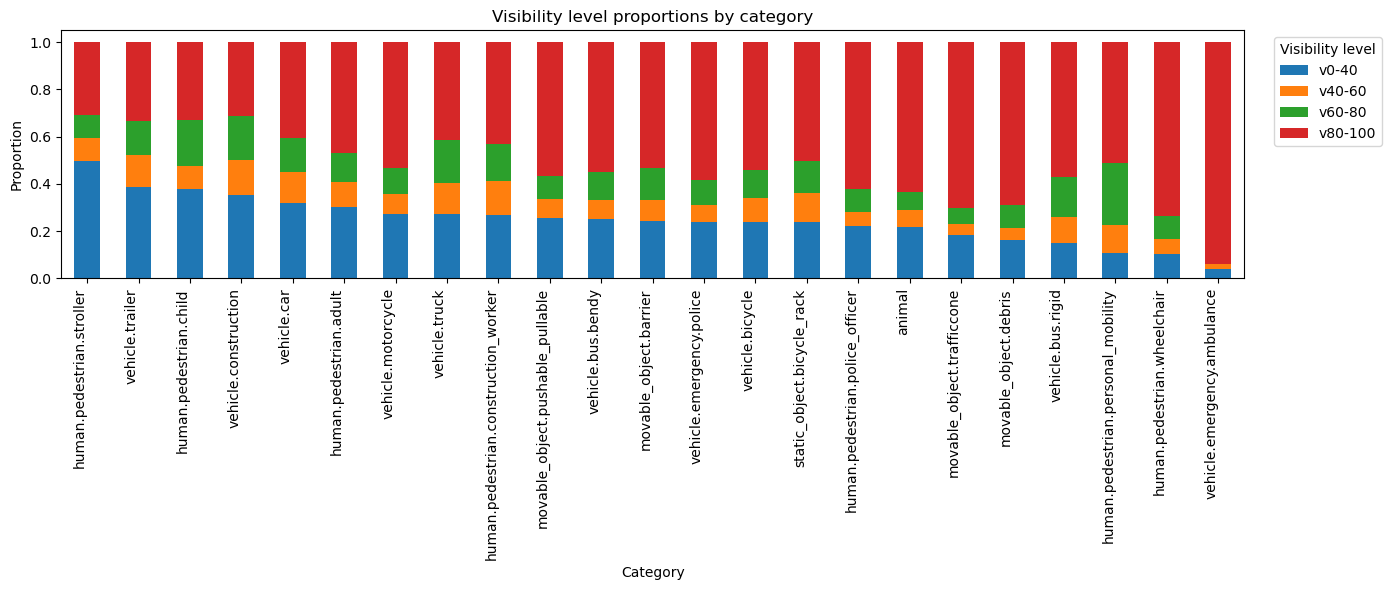

In [16]:
visibility_prop: pd.DataFrame = visibility_table.div(visibility_table.sum(axis=1), axis=0)

visibility_prop_sorted = visibility_prop.sort_values(
    by="v0-40",
    ascending=False
)

ax = visibility_prop_sorted.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6)
)

plt.title("Visibility level proportions by category")
plt.xlabel("Category")
plt.ylabel("Proportion")
plt.xticks(rotation=90, ha="right")

ax.legend(
    title="Visibility level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## Box size
box size in meters as width, length, height

In [17]:
# Let's split the size list into width, length, height.
#from documentaiton: "size":Bounding box size in meters: width, length, height.
size_cols: List = ["size_w", "size_l", "size_h"]

for idx, col in enumerate(size_cols):
    enriched_sa_df[col]=enriched_sa_df["size"].apply(lambda x: x[idx])

enriched_sa_df[["size","size_w", "size_l", "size_h"]].head()

,size,size_w,size_l,size_h
0,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
1,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
2,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
3,"[0.3, 0.291, 0.734]",0.3,0.291,0.734
4,"[0.3, 0.291, 0.734]",0.3,0.291,0.734


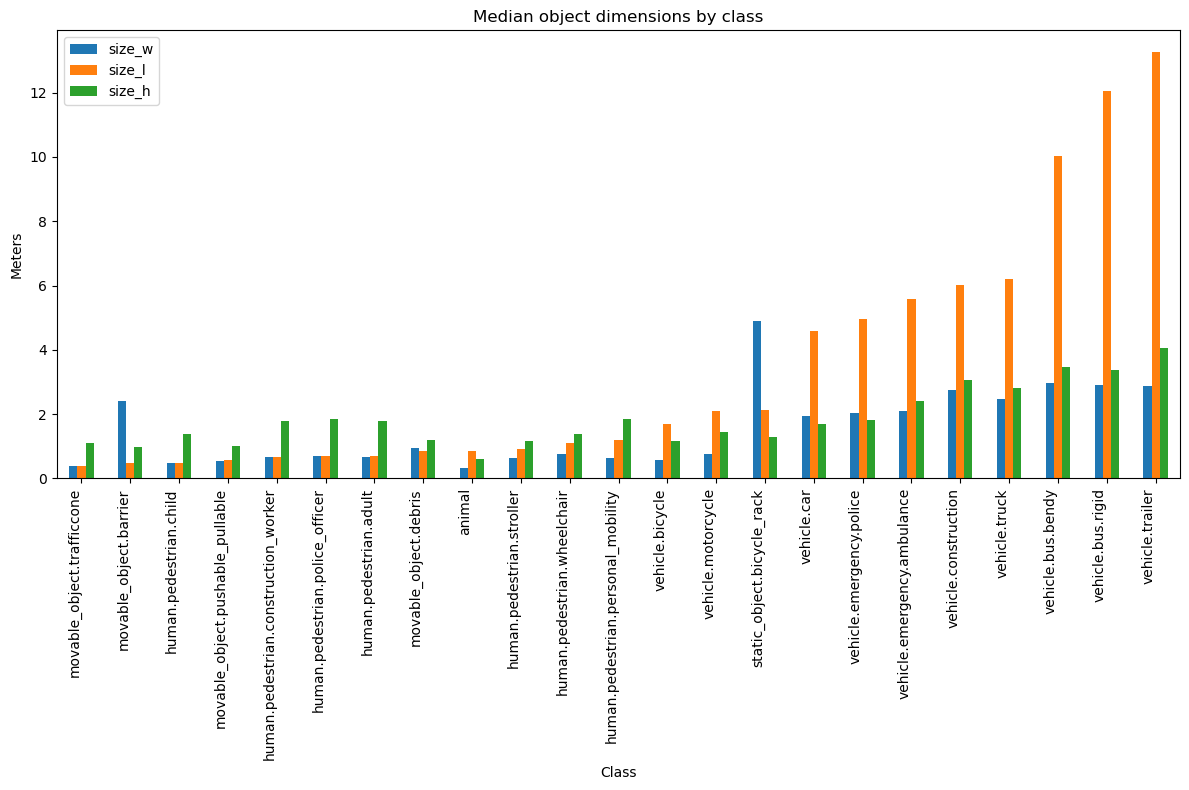

In [19]:
def plot_size_by_class(ann_df):
    med = (
        ann_df.groupby("category_name")[["size_w", "size_l", "size_h"]]
        .median()
        .sort_values("size_l")
    )
    med.plot(kind="bar", figsize=(12, 8))
    plt.title("Median object dimensions by class")
    plt.ylabel("Meters")
    plt.xlabel("Class")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.show()

plot_size_by_class(enriched_sa_df)

## Translation
Sample annotation table: 
* "translation":             <float> [3] -- Bounding box location in meters as center_x, center_y, center_z.

In [20]:
# # Create a new DataFrame
# features_df: pd.DataFrame = enriched_sa_df.copy()

# sample token -> lidar token
sample_to_lidar: pd.DataFrame = nusc_tables["sample"][["token", "data"]].copy()
sample_to_lidar["lidar_token"] = sample_to_lidar["data"].apply(
    lambda x: x.get("LIDAR_TOP") if isinstance(x, dict) else None
)
sample_to_lidar: pd.Series = sample_to_lidar.set_index("token")["lidar_token"]

# lidar token -> ego pose token
lidar_to_ego_pose: pd.Series = nusc_tables["sample_data"].set_index("token")["ego_pose_token"]

# ego pose token -> ego vehicle position
ego_pose_to_position: pd.Series = nusc_tables["ego_pose"].set_index("token")["translation"]

# Add the lidar token column
enriched_sa_df["lidar_token"] = enriched_sa_df["sample_token"].map(sample_to_lidar)

# Add the ego pose token column
enriched_sa_df["ego_pose_token"] = enriched_sa_df["lidar_token"].map(lidar_to_ego_pose)

# Add the ego vehicle position column
enriched_sa_df["ego_position"] = enriched_sa_df["ego_pose_token"].map(ego_pose_to_position)

# Add the ego_x, ego_y, ego_z columns
enriched_sa_df[["ego_x", "ego_y", "ego_z"]] = pd.DataFrame(
    enriched_sa_df["ego_position"].tolist(),
    index=enriched_sa_df.index
)

# Add the object position columns x, y, z
# "translation": Bounding box location in meters as center_x, center_y, center_z.
enriched_sa_df[["x", "y", "z"]] = pd.DataFrame(
    enriched_sa_df["translation"].tolist(),
    index=enriched_sa_df.index
)

enriched_sa_df[["translation", "x", "y", "z", "ego_x", "ego_y", "ego_z"]].head()

,translation,x,y,z,ego_x,ego_y,ego_z
0,"[993.884, 612.441, 0.675]",993.884,612.441,0.675,992.031025,633.339124,0.0
1,"[994.016, 612.335, 0.775]",994.016,612.335,0.775,1006.588808,620.729597,0.0
2,"[994.029, 612.524, 0.725]",994.029,612.524,0.725,1010.261466,612.897202,0.0
3,"[994.031, 612.51, 0.728]",994.031,612.510,0.728,1010.132835,610.811165,0.0
4,"[994.016, 612.335, 0.725]",994.016,612.335,0.725,1004.701847,622.473983,0.0


In [22]:
enriched_sa_df.head()

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name,visibility_level,size_w,size_l,size_h,lidar_token,ego_pose_token,ego_position,ego_x,ego_y,ego_z,x,y,z
0,70aecbe9b64f4722ab3c230391a3beb8,cd21dbfc3bd749c7b10a5c42562e0c42,6dd2cbf4c24b4caeb625035869bca7b5,4,[4d8821270b4a47e3a8a300cbec48188e],"[373.214, 1130.48, 1.25]","[0.621, 0.669, 1.642]","[0.9831098797903927, 0.0, 0.0, -0.18301629506281616]",a1721876c0944cdd92ebc3c75d55d693,1e8e35d365a441a18dd5503a0ee1c208,5,0,human.pedestrian.adult,v80-100,0.621,0.669,1.642,f582c6d34c8b403c8f3b66a8bb896892,f582c6d34c8b403c8f3b66a8bb896892,"[396.28709579417813, 1130.0546235114005, 0.0]",396.287096,1130.054624,0.0,373.214,1130.480,1.250
1,7fa3a688931b4500b7ce29d187d3b975,2ff86dc19c4644a1a88ce5ba848f56e5,6dd2cbf4c24b4caeb625035869bca7b5,4,[4d8821270b4a47e3a8a300cbec48188e],"[373.152, 1130.357, 1.25]","[0.621, 0.669, 1.642]","[0.9831098797903927, 0.0, 0.0, -0.18301629506281616]",1e8e35d365a441a18dd5503a0ee1c208,913072e56d6c4025b9b47ba085dd6d7c,6,0,human.pedestrian.adult,v80-100,0.621,0.669,1.642,a2491d8dad5548be842fac104d69d52a,a2491d8dad5548be842fac104d69d52a,"[396.6816902790987, 1125.2563692026397, 0.0]",396.681690,1125.256369,0.0,373.152,1130.357,1.250
2,93d5b79041c64693a5b32f1103a39a06,29e056fc277543c9bc42310b122c640e,6dd2cbf4c24b4caeb625035869bca7b5,1,[4d8821270b4a47e3a8a300cbec48188e],"[373.35, 1130.67, 1.123]","[0.621, 0.669, 1.642]","[0.9831098797903927, 0.0, 0.0, -0.18301629506281616]",3b24f083c0bf42d695a1040efdab7ffe,8bb63134d48840aaa2993f490855ff0d,2,0,human.pedestrian.adult,v0-40,0.621,0.669,1.642,faa171b7a8164f4cbf90b260af5c27f1,faa171b7a8164f4cbf90b260af5c27f1,"[419.5269830911931, 1104.8312849413196, 0.0]",419.526983,1104.831285,0.0,373.350,1130.670,1.123
3,ef63a697930c4b20a6b9791f423351da,ca9a282c9e77460f8360f564131a8af5,6dd2cbf4c24b4caeb625035869bca7b5,1,[4d8821270b4a47e3a8a300cbec48188e],"[373.256, 1130.419, 0.8]","[0.621, 0.669, 1.642]","[0.9831098797903927, 0.0, 0.0, -0.18301629506281616]",,7987617983634b119e383d8a29607fd7,1,0,human.pedestrian.adult,v0-40,0.621,0.669,1.642,9d9bf11fb0e144c8b446d54a8a00184f,9d9bf11fb0e144c8b446d54a8a00184f,"[411.3039349319818, 1180.8903791765097, 0.0]",411.303935,1180.890379,0.0,373.256,1130.419,0.800
4,7987617983634b119e383d8a29607fd7,39586f9d59004284a7114a68825e8eec,6dd2cbf4c24b4caeb625035869bca7b5,1,[4d8821270b4a47e3a8a300cbec48188e],"[373.256, 1130.419, 0.81]","[0.621, 0.669, 1.642]","[0.9831098797903927, 0.0, 0.0, -0.18301629506281616]",ef63a697930c4b20a6b9791f423351da,9acb7dfed3454f72b2874dda3bdacc48,1,0,human.pedestrian.adult,v0-40,0.621,0.669,1.642,4f792c8da81e4cb7aca1790654da1c27,4f792c8da81e4cb7aca1790654da1c27,"[409.7431520488096, 1176.6769733781416, 0.0]",409.743152,1176.676973,0.0,373.256,1130.419,0.810


# Features engineering

In [21]:
features_df: pd.DataFrame = enriched_sa_df.copy()

## 	2D Distance from Object to Ego Vehicle

In [22]:
# Add the lidar token column
features_df["lidar_sd_token"] = features_df["sample_token"].map(sample_to_lidar)

# Add the ego pose token column
features_df["ego_pose_token"] = features_df["lidar_sd_token"].map(lidar_to_ego_pose)

# Add the ego vehicle position column
features_df["ego_translation"] = features_df["ego_pose_token"].map(ego_pose_to_position)

# Add the 2D distance to the ego vehicle column
features_df["distance_ego_2d"] = np.sqrt(
    (features_df["x"] - features_df["ego_x"])**2 +
    (features_df["y"] - features_df["ego_y"])**2
)

# Add the 3D distance to the ego vehicle column
features_df["distance_ego_3d"] = np.sqrt(
    (features_df["x"] - features_df["ego_x"])**2 +
    (features_df["y"] - features_df["ego_y"])**2 +
    (features_df["z"] - features_df["ego_z"])**2
)

In [23]:
distance_bins = [0, 10, 20, 30, 40, 50, 70, 100, float("inf")]
distance_labels = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-70", "70-100", "100+"]

features_df["distance_bin"] = pd.cut(
    features_df["distance_ego_2d"],
    bins=distance_bins,
    labels=distance_labels,
    include_lowest=True,
    right=False
)

In [24]:
features_df[
    [
        "category_name", "translation", "x", "y", "z",
        "ego_x", "ego_y", "ego_z",
        "distance_ego_2d", "distance_ego_3d", "distance_bin"
    ]
].head()

,category_name,translation,x,y,z,ego_x,ego_y,ego_z,distance_ego_2d,distance_ego_3d,distance_bin
0,movable_object.trafficcone,"[993.884, 612.441, 0.675]",993.884,612.441,0.675,992.031025,633.339124,0.0,20.980112,20.990968,20-30
1,movable_object.trafficcone,"[994.016, 612.335, 0.775]",994.016,612.335,0.775,1006.588808,620.729597,0.0,15.117697,15.137549,10-20
2,movable_object.trafficcone,"[994.029, 612.524, 0.725]",994.029,612.524,0.725,1010.261466,612.897202,0.0,16.236755,16.252934,10-20
3,movable_object.trafficcone,"[994.031, 612.51, 0.728]",994.031,612.510,0.728,1010.132835,610.811165,0.0,16.191206,16.207564,10-20
4,movable_object.trafficcone,"[994.016, 612.335, 0.725]",994.016,612.335,0.725,1004.701847,622.473983,0.0,14.730455,14.748286,10-20


## Box volume

In [25]:
features_df["volume"]=features_df["size"].apply(lambda x: x[0]*x[1]*x[2])
features_df[["size","volume"]].head()

,size,volume
0,"[0.3, 0.291, 0.734]",0.064078
1,"[0.3, 0.291, 0.734]",0.064078
2,"[0.3, 0.291, 0.734]",0.064078
3,"[0.3, 0.291, 0.734]",0.064078
4,"[0.3, 0.291, 0.734]",0.064078


## Aspect ratio

In [26]:
n_zero = (features_df["size_w"] == 0).sum()
if n_zero > 0:
    print(f"Warning: {n_zero} rows have size_w = 0. aspect_ratio_l_w set to NaN for these rows.")

features_df["aspect_ratio_l_w"] = np.where(
    features_df["size_w"] == 0,
    np.nan,
    features_df["size_l"] / features_df["size_w"]
)

In [27]:
features_df[["size_l","size_w","aspect_ratio_l_w"]].head()

,size_l,size_w,aspect_ratio_l_w
0,0.291,0.3,0.97
1,0.291,0.3,0.97
2,0.291,0.3,0.97
3,0.291,0.3,0.97
4,0.291,0.3,0.97


## LiDAR

* ```has_lidar```: the object is supported by LiDAR, meaning at least some LiDAR points fall on it.
* ```low_lidar_support```: the object has LiDAR support, but it is weak, meaning only a small number of LiDAR points fall on it.

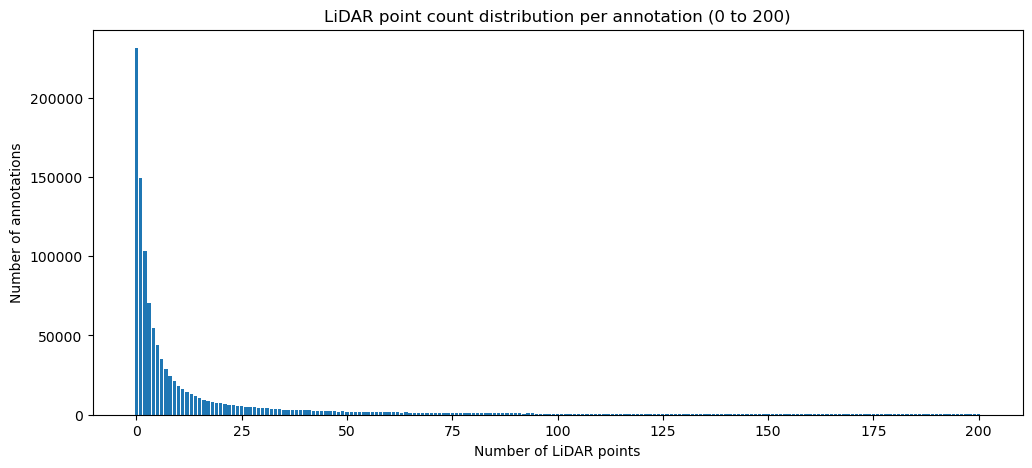

In [29]:
# ============================================================
# Plot: LiDAR point count distribution per annotation (51 to 200)
#
# Question answered:
# How common are mid-range LiDAR point counts, beyond the sparse-support region?
# ============================================================

import matplotlib.pyplot as plt

def plot_point_count_distribution(df, col, sensor_name, max_points=200):
    pts_freq = (
        df[col]
        .value_counts()
        .sort_index()
        .loc[:max_points]
    )

    plt.figure(figsize=(12, 5))
    plt.bar(pts_freq.index, pts_freq.values)
    plt.xlabel(f"Number of {sensor_name} points")
    plt.ylabel("Number of annotations")
    plt.title(f"{sensor_name} point count distribution per annotation (0 to {max_points})")
    plt.show()
    
plot_point_count_distribution(features_df, "num_lidar_pts", "LiDAR", max_points=200)

num_lidar_pts is not normally distributed.

In [30]:
features_df.groupby("category_name")["num_lidar_pts"].median().sort_values(ascending=False)

category_name
vehicle.bus.rigid                       21.0
vehicle.trailer                         17.0
vehicle.bus.bendy                       16.0
vehicle.emergency.ambulance             13.0
human.pedestrian.wheelchair             13.0
vehicle.truck                           10.0
static_object.bicycle_rack              10.0
vehicle.emergency.police                10.0
vehicle.construction                    10.0
movable_object.barrier                   7.0
movable_object.pushable_pullable         5.0
movable_object.debris                    5.0
human.pedestrian.personal_mobility       5.0
human.pedestrian.police_officer          4.0
vehicle.bicycle                          4.0
vehicle.motorcycle                       4.0
vehicle.car                              4.0
animal                                   3.0
human.pedestrian.adult                   3.0
human.pedestrian.construction_worker     3.0
human.pedestrian.stroller                2.0
human.pedestrian.child                   

In [31]:
# TODO: refactor and create a function 
lidar_support_summary = features_df.groupby("category_name").agg(
    n_objects=("category_name", "size"),
    lidar_mean=("num_lidar_pts", "mean"),
    lidar_median=("num_lidar_pts", "median"),
    pct_no_lidar=("num_lidar_pts", lambda s: (s == 0).mean())
).sort_values("pct_no_lidar", ascending=True)

lidar_support_summary

,n_objects,lidar_mean,lidar_median,pct_no_lidar
category_name,,,,
human.pedestrian.wheelchair,503,25.890656,13.0,0.029821
human.pedestrian.personal_mobility,395,19.562025,5.0,0.078481
vehicle.bus.rigid,14501,295.658230,21.0,0.089442
movable_object.pushable_pullable,24605,25.090266,5.0,0.113310
human.pedestrian.police_officer,727,16.280605,4.0,0.115543
vehicle.construction,14671,90.200872,10.0,0.116829
static_object.bicycle_rack,2713,69.091043,10.0,0.119794
vehicle.trailer,24860,199.149598,17.0,0.127233
vehicle.bus.bendy,1820,234.021978,16.0,0.129670


LiDAR support is much more consistent than radar support across categories, with lower zero-support rates for most object types. However, LiDAR coverage remains strongly class-dependent. Large vehicle categories such as buses, trucks, trailers, and construction vehicles receive much denser LiDAR support, while pedestrians, bicycles, and traffic cones are often represented by only a few points. This suggests that **LiDAR is a strong modality overall**, but its object-level evidence can still be sparse for small or thin classes.

In [33]:
def print_point_count_intervals(df, col):
    x = df[col]

    print(f"{col} distribution:")
    print(f"0 points   : {(x == 0).mean() * 100:.2f}%")
    print(f"1 point    : {(x == 1).mean() * 100:.2f}%")
    print(f"2 points   : {(x == 2).mean() * 100:.2f}%")
    print(f"3-4 points : {x.between(3, 4).mean() * 100:.2f}%")
    print(f"5-9 points : {x.between(5, 9).mean() * 100:.2f}%")
    print(f"10+ points : {(x >= 10).mean() * 100:.2f}%")
    
print_point_count_intervals(features_df, "num_lidar_pts")


num_lidar_pts distribution:
0 points   : 19.82%
1 point    : 12.81%
2 points   : 8.84%
3-4 points : 10.77%
5-9 points : 13.18%
10+ points : 34.57%


* LiDAR often gives few points.
* About 23% of objects have no LiDAR points,
* and about 30% have only 1 to 4 points.
* So weak LiDAR support is common in this dataset.

In [34]:
# TODO: use sparse LiDAR to usable LiDAR.
features_df["no_lidar_support"] = features_df["num_lidar_pts"] == 0
features_df["low_lidar_support"] = features_df["num_lidar_pts"].between(1, 4)
features_df["usable_lidar_support"] = features_df["num_lidar_pts"] >= 5

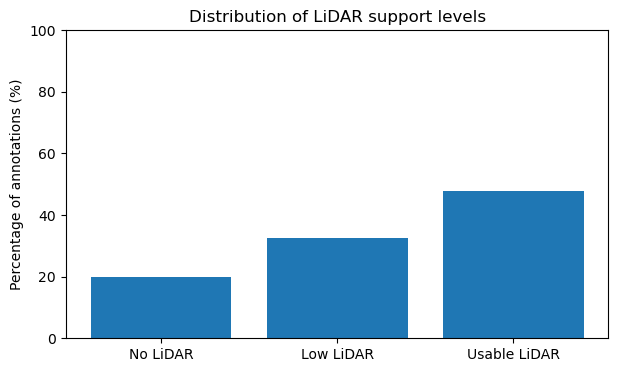

In [35]:
# what percentage of annotations fall into each LiDAR support group?
def plot_support_distribution(
    df: pd.DataFrame,
    no_col: str,
    low_col: str,
    usable_col: str,
    sensor_name: str
) -> None:
    """Plot percentage distribution of no/low/usable support."""
    support = pd.Series({
        f"No {sensor_name}": df[no_col].sum(),
        f"Low {sensor_name}": df[low_col].sum(),
        f"Usable {sensor_name}": df[usable_col].sum()
    })

    support_pct = 100 * support / support.sum()

    plt.figure(figsize=(7, 4))
    plt.bar(support_pct.index, support_pct.values)
    plt.ylabel("Percentage of annotations (%)")
    plt.title(f"Distribution of {sensor_name} support levels")
    plt.ylim(0, 100)
    plt.show()
    
plot_support_distribution(
    df=features_df,
    no_col="no_lidar_support",
    low_col="low_lidar_support",
    usable_col="usable_lidar_support",
    sensor_name="LiDAR"
)

In [36]:
features_df[["category_name", "num_lidar_pts","no_lidar_support","low_lidar_support","usable_lidar_support"]].head()

,category_name,num_lidar_pts,no_lidar_support,low_lidar_support,usable_lidar_support
0,movable_object.trafficcone,2,False,True,False
1,movable_object.trafficcone,1,False,True,False
2,movable_object.trafficcone,2,False,True,False
3,movable_object.trafficcone,2,False,True,False
4,movable_object.trafficcone,2,False,True,False


## Radar

* ```has_radar```: the object is supported by radar, meaning at least some radar points fall on it.
* ```low_radar_support```: the object has radar support, but it is weak, meaning only a small number of radar points fall on it.

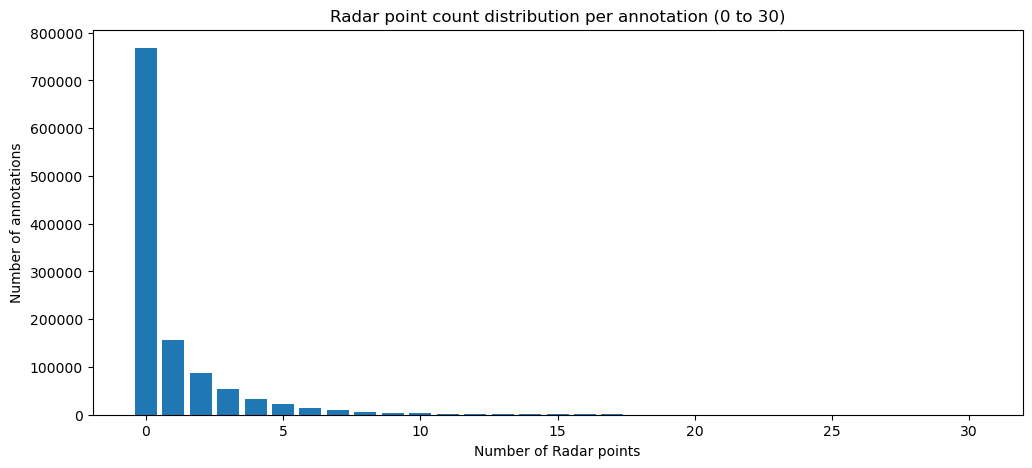

In [37]:
plot_point_count_distribution(features_df, "num_radar_pts", "Radar", max_points=30)

```num_radar_pts``` is not normally distributed.

In [38]:
features_df["num_radar_pts"].describe()

count    1.166187e+06
mean     9.770097e-01
std      2.125434e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      5.800000e+01
Name: num_radar_pts, dtype: float64

In [39]:
features_df.groupby("category_name")["num_radar_pts"].mean().sort_values(ascending=False)

category_name
vehicle.bus.rigid                       4.643197
vehicle.bus.bendy                       4.138462
static_object.bicycle_rack              3.448950
vehicle.trailer                         3.285438
vehicle.truck                           2.599995
vehicle.construction                    2.367800
vehicle.emergency.police                1.847962
vehicle.emergency.ambulance             1.714286
vehicle.car                             1.232195
human.pedestrian.wheelchair             0.862823
vehicle.motorcycle                      0.532139
movable_object.debris                   0.441645
human.pedestrian.personal_mobility      0.432911
human.pedestrian.police_officer         0.403026
vehicle.bicycle                         0.332068
movable_object.barrier                  0.244899
movable_object.pushable_pullable        0.226133
human.pedestrian.construction_worker    0.163301
human.pedestrian.adult                  0.153760
human.pedestrian.child                  0.114230
movabl

In [40]:
radar_support_summary = features_df.groupby("category_name").agg(
    n_objects=("category_name", "size"),
    radar_mean=("num_radar_pts", "mean"),
    radar_median=("num_radar_pts", "median"),
    pct_no_radar=("num_radar_pts", lambda s: (s == 0).mean())
).sort_values("pct_no_radar", ascending=True)

radar_support_summary

,n_objects,radar_mean,radar_median,pct_no_radar
category_name,,,,
vehicle.bus.bendy,1820,4.138462,3.0,0.291209
vehicle.trailer,24860,3.285438,2.0,0.358930
human.pedestrian.wheelchair,503,0.862823,1.0,0.363817
static_object.bicycle_rack,2713,3.448950,1.0,0.368227
vehicle.bus.rigid,14501,4.643197,2.0,0.377422
vehicle.emergency.ambulance,49,1.714286,2.0,0.408163
vehicle.truck,88519,2.599995,1.0,0.420497
vehicle.construction,14671,2.367800,1.0,0.429964
vehicle.emergency.police,638,1.847962,1.0,0.462382


Radar support is highly class-dependent. Large vehicle categories such as buses, trailers, trucks, and construction vehicles usually receive multiple radar points, while pedestrians, bicycles, motorcycles, traffic cones, and other small objects are often completely unsupported by radar. For many vulnerable-road-user classes, the median radar point count is zero and the proportion of zero-radar annotations is very high.

* Radar is specialized, not universal
* It works best on large rigid vehicles
* It is often absent for pedestrians and small objects
* Even in common classes like cars, radar is sparse and inconsistent

In [41]:
pct_no_radar_by_cat = (
    features_df.groupby("category_name")["num_radar_pts"]
    .apply(lambda s: (s == 0).mean())
)

def radar_support_group(p):
    if p < 0.4:
        return "radar_well_supported"
    elif p <= 0.7:
        return "radar_partial"
    else:
        return "radar_weak"

features_df["radar_support_group_cat"] = (
    features_df["category_name"].map(pct_no_radar_by_cat).apply(radar_support_group)
)

In [42]:
features_df["num_radar_pts"].value_counts()

num_radar_pts
0     767877
1     156313
2      87787
3      53076
4      33669
5      21825
6      14294
7       9012
8       5914
9       3907
10      2762
11      2138
12      1621
13      1219
14       952
15       753
16       588
17       486
18       399
19       308
20       245
21       208
22       176
23       126
24        92
25        89
26        49
29        44
27        44
28        40
30        35
31        27
32        23
34        15
35        11
33        10
38         8
36         7
37         6
39         6
40         5
43         4
41         3
45         3
49         3
54         2
47         2
58         1
52         1
44         1
51         1
Name: count, dtype: int64

Based on the count of unique value, I can select threshold for ```low_radar_support```

In [43]:
print_point_count_intervals(features_df, "num_radar_pts")

num_radar_pts distribution:
0 points   : 65.85%
1 point    : 13.40%
2 points   : 7.53%
3-4 points : 7.44%
5-9 points : 4.71%
10+ points : 1.07%


In [44]:
features_df["usable_radar_support"] = features_df["num_radar_pts"] >= 3
features_df["low_radar_support"] = features_df["num_radar_pts"].between(1, 2)
features_df["no_radar_support"] = features_df["num_radar_pts"] == 0

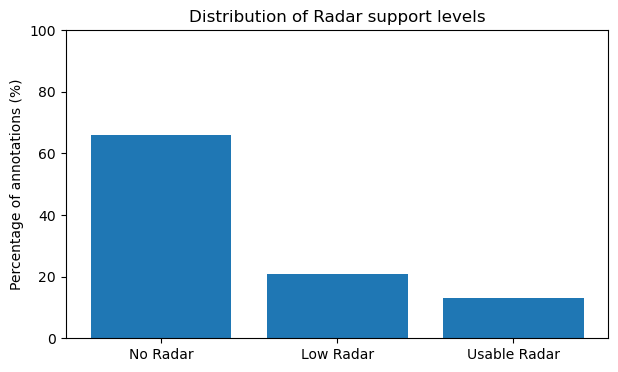

In [45]:
plot_support_distribution(
    df=features_df,
    no_col="no_radar_support",
    low_col="low_radar_support",
    usable_col="usable_radar_support",
    sensor_name="Radar"
)

In [46]:
features_df[["category_name","num_radar_pts", "usable_radar_support","low_radar_support", "no_radar_support"]].tail()

,category_name,num_radar_pts,usable_radar_support,low_radar_support,no_radar_support
1166182,human.pedestrian.adult,0,False,False,True
1166183,human.pedestrian.adult,1,False,True,False
1166184,human.pedestrian.adult,0,False,False,True
1166185,human.pedestrian.adult,0,False,False,True
1166186,human.pedestrian.adult,0,False,False,True


## Camera
I use the nuScenes helper ```get_sample_data()``` from ```nuscenes.py``` to check whether a given object annotation appears in each camera view of the same sample. For each object, I go through the 6 camera images, keep only the views where nuScenes returns a box for that annotation, and record which cameras can see it. For every visible view, I then project the 3D box corners into the image with ```view_points()```, following the same projection idea used in ```geometry_utils.py```, and compute the box area in pixels. This gives me camera features such as how many cameras see the object, which cameras see it, and the maximum and average projected box area across those views.

In [47]:
features_df.head(2)

,annotation_token,sample_token,instance_token,visibility_token,attribute_tokens,translation,size,rotation,prev_ann,next_ann,num_lidar_pts,num_radar_pts,category_name,visibility_level,size_w,size_l,size_h,lidar_token,ego_pose_token,ego_position,ego_x,ego_y,ego_z,x,y,z,lidar_sd_token,ego_translation,distance_ego_2d,distance_ego_3d,distance_bin,volume,aspect_ratio_l_w,no_lidar_support,low_lidar_support,usable_lidar_support,radar_support_group_cat,usable_radar_support,low_radar_support,no_radar_support
0,2cd832644d09479389ed0785e5de85c9,c36eb85918a84a788e236f5c9eef2b05,5e2b6fd1fab74d04a79eefebbec357bb,3,[],"[993.884, 612.441, 0.675]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",5cd018cb2448415ab8aff4dc7256999a,,2,0,movable_object.trafficcone,v60-80,0.3,0.291,0.734,e17d40d53225461d87d40a97f18eb0c2,e17d40d53225461d87d40a97f18eb0c2,"[992.0310248984529, 633.3391241886349, 0.0]",992.031025,633.339124,0.0,993.884,612.441,0.675,e17d40d53225461d87d40a97f18eb0c2,"[992.0310248984529, 633.3391241886349, 0.0]",20.980112,20.990968,20-30,0.064078,0.97,False,True,False,radar_weak,False,False,True
1,6babb6b4d3ac4dc183091df3cc9a6f8a,4dfab70f0b3f405bbf17f7c534d2dd91,5e2b6fd1fab74d04a79eefebbec357bb,2,[],"[994.016, 612.335, 0.775]","[0.3, 0.291, 0.734]","[-0.04208490861058176, 0.0, 0.0, 0.9991140377690821]",54cb06c51f774827a32aeec481bdee9b,68df06a01e31417fac56e0348940601c,1,0,movable_object.trafficcone,v40-60,0.3,0.291,0.734,e68c66ab18ac4e049321ba61591496b0,e68c66ab18ac4e049321ba61591496b0,"[1006.5888080656023, 620.7295966987493, 0.0]",1006.588808,620.729597,0.0,994.016,612.335,0.775,e68c66ab18ac4e049321ba61591496b0,"[1006.5888080656023, 620.7295966987493, 0.0]",15.117697,15.137549,10-20,0.064078,0.97,False,True,False,radar_weak,False,False,True


### Box area

In [48]:
import pandas as pd
import numpy as np
from nuscenes.utils.geometry_utils import BoxVisibility, view_points

How to get the box area from cameras?
1. get the camera ```sample_data``` token from the ```sample```
2. call ```nusc.get_sample_data(...)```
3. keep only your target annotation box
4. project its 3D corners with ```view_points(...)```
5. take the min/max x and y
6. compute ```width * height```

In [49]:
help(nusc.get_sample_data)
help(nusc.get)
help(view_points)

Help on method get_sample_data in module nuscenes.nuscenes:

get_sample_data(sample_data_token: str, box_vis_level: nuscenes.utils.geometry_utils.BoxVisibility = <BoxVisibility.ANY: 1>, selected_anntokens: List[str] = None, use_flat_vehicle_coordinates: bool = False) -> Tuple[str, List[nuscenes.utils.data_classes.Box], <built-in function array>] method of nuscenes.nuscenes.NuScenes instance
    Returns the data path as well as all annotations related to that sample_data.
    Note that the boxes are transformed into the current sensor's coordinate frame.
    :param sample_data_token: Sample_data token.
    :param box_vis_level: If sample_data is an image, this sets required visibility for boxes.
    :param selected_anntokens: If provided only return the selected annotation.
    :param use_flat_vehicle_coordinates: Instead of the current sensor's coordinate frame, use ego frame which is
                                         aligned to z-plane in the world.
    :return: (data_path, box

In [50]:
import numpy as np
from nuscenes.utils.data_classes import Box
from nuscenes.utils.geometry_utils import view_points


# Adapted from nuscenes.utils.geometry_utils.box_in_image:
# project box corners into the image and keep only corners with positive depth.
def box_area_px(
    box: Box,
    intrinsic: np.ndarray,
    img_w: int,
    img_h: int,
    verbose: bool = False
) -> float:
    """
    Compute the projected 2D box area in image pixels.

    The box must already be in camera coordinates.

    Parameters
    ----------
    box : Box
        nuScenes Box object in camera coordinates.
    intrinsic : np.ndarray
        Camera intrinsic matrix.
    img_w : int
        Image width in pixels.
    img_h : int
        Image height in pixels.
    verbose : bool, default=False
        Reserved for optional debugging.

    Returns
    -------
    float
        Area in pixels of the smallest 2D rectangle covering the projected
        visible box corners. Returns 0.0 if no corner is in front of the camera.
    """
    corners_3d: np.ndarray = box.corners()
    corners_2d: np.ndarray = view_points(corners_3d, intrinsic, normalize=True)[:2, :]

    in_front: np.ndarray = corners_3d[2, :] > 0.1 # True if a corner is at least 0.1 meter in front of the camera.

    if not np.any(in_front):
        return 0.0

    x: np.ndarray = np.clip(a=corners_2d[0, in_front], a_min=0, a_max=img_w)
    y: np.ndarray = np.clip(a=corners_2d[1, in_front], a_min=0, a_max=img_h)

    width: float = max(0.0, float(x.max() - x.min()))
    height: float = max(0.0, float(y.max() - y.min()))

    return float(width * height)

def get_camera_features(nusc: NuScenes, ann_token: str) -> Dict[str, Any]:
    # Start from one object annotation
    ann: Dict[str, Any] = nusc.get("sample_annotation", ann_token)

    # Find the frame where this object appears
    sample: Dict[str, Any] = nusc.get("sample", ann["sample_token"])

    visible_cam_names: List[str] = []
    visible_cam_areas: List[float] = []

    # Check each camera in that frame
    for cam_name, sd_token in sample["data"].items():
        if not cam_name.startswith("CAM"):
            continue

        # Get image size
        sd: Dict[str, Any] = nusc.get("sample_data", sd_token)
        img_w: int = sd["width"]
        img_h: int = sd["height"]

        # Ask nuScenes for this annotation in this camera
        _, boxes, camera_intrinsic = nusc.get_sample_data(
            sd_token,
            box_vis_level=BoxVisibility.ANY,
            selected_anntokens=[ann_token]
        )

        # If no box comes back, the object is not visible there
        if not boxes:
            continue

        area: float = box_area_px(boxes[0], camera_intrinsic, img_w, img_h)

        visible_cam_names.append(cam_name)
        visible_cam_areas.append(area)

    if visible_cam_areas:
        best_idx: int = int(np.argmax(visible_cam_areas))
        max_box_area_px: float = float(np.max(visible_cam_areas))
        mean_box_area_px: float = float(np.mean(visible_cam_areas))
        best_camera_name: Optional[str] = visible_cam_names[best_idx]
    else:
        max_box_area_px = 0.0
        mean_box_area_px = 0.0
        best_camera_name = None

    return {
        "num_visible_cams": len(visible_cam_names),
        "visible_cam_names": visible_cam_names,
        "has_any_camera_view": len(visible_cam_names) > 0,
        "max_box_area_px": max_box_area_px,
        "mean_box_area_px": mean_box_area_px,
        "best_camera_name": best_camera_name,
    }


# ------------------------------------------------------------
# test on one annotation first
# ------------------------------------------------------------
test_ann_token = features_df.iloc[0]["annotation_token"]

test_result = get_camera_features(nusc, test_ann_token)

print("Test annotation token:", test_ann_token)
pprint(test_result)

Test annotation token: 2cd832644d09479389ed0785e5de85c9
{'best_camera_name': 'CAM_BACK_LEFT',
 'has_any_camera_view': True,
 'max_box_area_px': 1272.9490256449087,
 'mean_box_area_px': 1272.9490256449087,
 'num_visible_cams': 1,
 'visible_cam_names': ['CAM_BACK_LEFT']}


In [52]:
# TODO: Current computation time: 19m26s. Can I optimize the computation time? 

def add_camera_feature_columns(df: pd.DataFrame, nusc) -> pd.DataFrame:
    camera_cols: List[str] = [
        "num_visible_cams",
        "visible_cam_names",
        "has_any_camera_view",
        "max_box_area_px",
        "mean_box_area_px",
        "best_camera_name",
    ]

    df = df.drop(columns=camera_cols, errors="ignore").copy()

    unique_tokens = df["annotation_token"].unique()

    feature_map: Dict[str, Dict[str, Any]] = {
        ann_token: get_camera_features(nusc, ann_token)
        for ann_token in tqdm(unique_tokens, desc="Computing camera features")
    }

    camera_features_df = df["annotation_token"].map(feature_map).apply(pd.Series)
    camera_features_df.index = df.index

    return pd.concat([df, camera_features_df], axis=1)

# For each annotation (1.16M times):
#     → find its sample
#     → loop over 6 cameras
#     → project 3D box into image
#     → compute box area

features_df =  add_camera_feature_columns(features_df, nusc)    

Computing camera features:   0%|          | 0/1166187 [00:00<?, ?it/s]

In [53]:
features_df[
[
    "annotation_token",
    "num_visible_cams",
    "visible_cam_names",
    "has_any_camera_view",
    "max_box_area_px",
    "mean_box_area_px",
    "best_camera_name",
]
].head()

,annotation_token,num_visible_cams,visible_cam_names,has_any_camera_view,max_box_area_px,mean_box_area_px,best_camera_name
0,2cd832644d09479389ed0785e5de85c9,1,[CAM_BACK_LEFT],True,1272.949026,1272.949026,CAM_BACK_LEFT
1,6babb6b4d3ac4dc183091df3cc9a6f8a,2,"[CAM_BACK_LEFT, CAM_FRONT_LEFT]",True,3626.434362,3566.396982,CAM_FRONT_LEFT
2,35034272eb1f413187ae7b6affb6ec7a,1,[CAM_BACK_LEFT],True,1762.659182,1762.659182,CAM_BACK_LEFT
3,173a50411564442ab195e132472fde71,1,[CAM_BACK_LEFT],True,1874.165639,1874.165639,CAM_BACK_LEFT
4,68df06a01e31417fac56e0348940601c,1,[CAM_BACK_LEFT],True,3173.976467,3173.976467,CAM_BACK_LEFT


### box features

In [54]:
features_df.groupby("category_name")["max_box_area_px"].median().sort_values(ascending=False)

category_name
vehicle.trailer                         30526.772097
vehicle.bus.bendy                       22692.833690
vehicle.construction                    20975.839308
vehicle.bus.rigid                       16995.553781
vehicle.emergency.police                15943.264377
vehicle.truck                           14785.567523
static_object.bicycle_rack              13505.558717
human.pedestrian.wheelchair             12006.467964
vehicle.car                              9938.073175
human.pedestrian.personal_mobility       9488.331888
vehicle.motorcycle                       6232.661792
vehicle.emergency.ambulance              5915.805355
vehicle.bicycle                          5874.092623
movable_object.barrier                   4750.762405
movable_object.debris                    4390.091751
human.pedestrian.construction_worker     4330.000091
human.pedestrian.stroller                3430.436688
human.pedestrian.adult                   3407.891470
movable_object.pushable_pullable

In [55]:
features_df["max_box_area_px"].quantile([0.25, 0.5, 0.75, 0.9])

0.25     2296.526880
0.50     6896.310597
0.75    21840.973966
0.90    71575.885326
Name: max_box_area_px, dtype: float64

In [56]:
q25 = features_df["max_box_area_px"].quantile(0.25)
q50 = features_df["max_box_area_px"].quantile(0.50)

features_df["weak_camera_view"] = features_df["max_box_area_px"] <= q25
features_df["limited_camera_view"] = features_df["max_box_area_px"].between(q25, q50, inclusive="right")
features_df["good_camera_view"] = features_df["max_box_area_px"] > q50

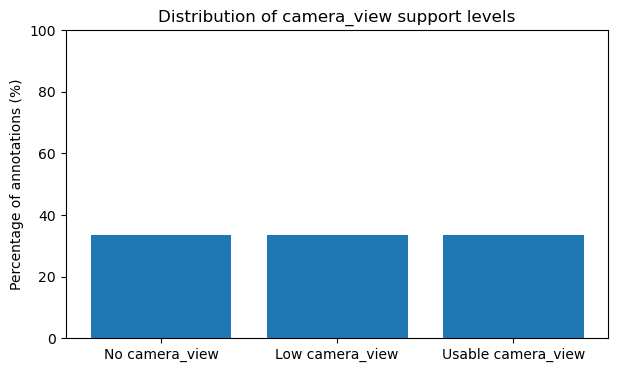

In [57]:
plot_support_distribution(
    df=features_df,
    no_col="weak_camera_view",
    low_col="limited_camera_view",
    usable_col="limited_camera_view",
    sensor_name="camera_view"
)

In [58]:
features_df.columns

Index(['annotation_token', 'sample_token', 'instance_token',
       'visibility_token', 'attribute_tokens', 'translation', 'size',
       'rotation', 'prev_ann', 'next_ann', 'num_lidar_pts', 'num_radar_pts',
       'category_name', 'visibility_level', 'size_w', 'size_l', 'size_h',
       'lidar_token', 'ego_pose_token', 'ego_position', 'ego_x', 'ego_y',
       'ego_z', 'x', 'y', 'z', 'lidar_sd_token', 'ego_translation',
       'distance_ego_2d', 'distance_ego_3d', 'distance_bin', 'volume',
       'aspect_ratio_l_w', 'no_lidar_support', 'low_lidar_support',
       'usable_lidar_support', 'radar_support_group_cat',
       'usable_radar_support', 'low_radar_support', 'no_radar_support',
       'num_visible_cams', 'visible_cam_names', 'has_any_camera_view',
       'max_box_area_px', 'mean_box_area_px', 'best_camera_name',
       'weak_camera_view', 'limited_camera_view', 'good_camera_view'],
      dtype='object')

In [59]:
# ------------------------------------------------------------
# Step 12: inspect the new threshold features
# ------------------------------------------------------------
print(features_df["weak_camera_view"].value_counts())
print(features_df["limited_camera_view"].value_counts())
print(features_df["good_camera_view"].value_counts())

weak_camera_view
False    874640
True     291547
Name: count, dtype: int64
limited_camera_view
False    874640
True     291547
Name: count, dtype: int64
good_camera_view
False    583094
True     583093
Name: count, dtype: int64


# Exploratory Data Analysis

In [59]:
# # ============================================================
# # Column groups for EDA
# # Keep columns grouped by the question they help answer.
# # ============================================================

# # Object identifiers for traceability and grouping.
# id_cols = [
#     "annotation_token",
#     "sample_token",
#     "instance_token",
# ]

# # Class label and visibility information.
# context_cols = [
#     "category_name",
#     "visibility_level",
# ]

# # Geometry and intrinsic difficulty features.
# geometry_cols = [
#     "size_w",
#     "size_l",
#     "size_h",
#     "volume",
#     "aspect_ratio_l_w",
#     "x",
#     "y",
#     "z",
#     "distance_ego_2d",
#     "distance_ego_3d",
# ]

# # LiDAR support features.
# lidar_cols = [
#     "num_lidar_pts",
#     "no_lidar_support",
#     "low_lidar_support",
#     "usable_lidar_support",
# ]

# # Radar support features.
# radar_cols = [
#     "num_radar_pts",
#     "has_radar",
#     "low_radar_support",
#     "no_radar_support",
#     "radar_support_group_cat",
# ]

# # Camera support features.
# camera_cols = [
#     "num_visible_cams",
#     "has_any_camera_view",
#     "max_box_area_px",
#     "mean_box_area_px",
#     "best_camera_name",
#     "weak_camera_view",
#     "limited_camera_view",
#     "good_camera_view",
#     "multi_camera_object",
#     "single_camera_object",
#     "multi_camera_good_view",
#     "single_camera_weak_view",
# ]

# # Fusion and complementarity flags.
# fusion_cols = [
#     "low_lidar_good_camera",
#     "no_lidar_good_camera",
#     "low_radar_good_camera",
#     "no_radar_good_camera",
#     "weak_camera_usable_lidar",
#     "weak_camera_has_radar",
#     "weak_camera_any_range_support",
#     "weak_all_modalities",
#     "limited_camera_low_lidar_no_radar",
#     "good_camera_usable_lidar",
#     "good_camera_has_radar",
#     "strong_all_modalities",
# ]

# # Final column list for the EDA dataframe.
# eda_cols = (
#     id_cols
#     + context_cols
#     + geometry_cols
#     + lidar_cols
#     + radar_cols
#     + camera_cols
#     + fusion_cols
# )

# eda_df = features_df[eda_cols].copy()

In [60]:
raw_eda_df = features_df.copy()

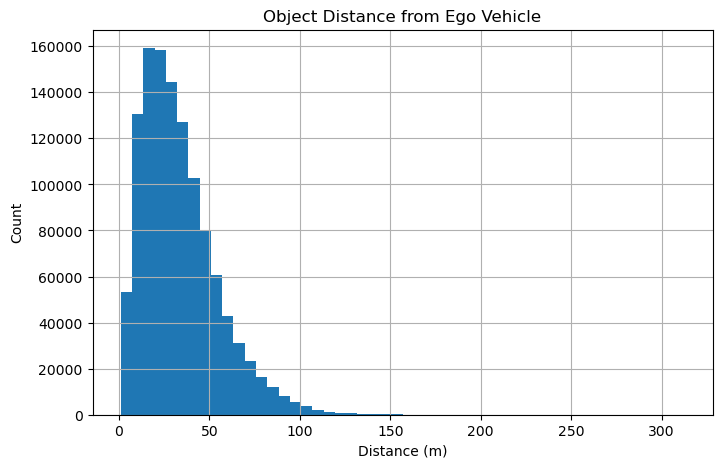

In [61]:
plt.figure(figsize=(8, 5))
raw_eda_df["distance_ego_2d"].hist(bins=50)
plt.title("Object Distance from Ego Vehicle")
plt.xlabel("Distance (m)")
plt.ylabel("Count")
plt.show()

## Sanity checks
The dataset is well curated

In [62]:
# Which objects dominate the dataset and which are underrepresented?
class_counts:pd.Series = raw_eda_df["category_name"].value_counts().sort_values(ascending=False)
class_counts

category_name
vehicle.car                             493322
human.pedestrian.adult                  208240
movable_object.barrier                  152087
movable_object.trafficcone               97959
vehicle.truck                            88519
vehicle.trailer                          24860
movable_object.pushable_pullable         24605
vehicle.construction                     14671
vehicle.bus.rigid                        14501
vehicle.motorcycle                       12617
vehicle.bicycle                          11859
human.pedestrian.construction_worker      9161
movable_object.debris                     3016
static_object.bicycle_rack                2713
human.pedestrian.child                    2066
vehicle.bus.bendy                         1820
human.pedestrian.stroller                 1072
animal                                     787
human.pedestrian.police_officer            727
vehicle.emergency.police                   638
human.pedestrian.wheelchair                503

## Clean the DataFrame for statistical analysis

In [63]:
keep_category = class_counts[(class_counts>=30)].index
removed_category = class_counts[(class_counts<30)].index

print("Kept category:",keep_category)
print("\nRemoved category due to low count number:",removed_category)

eda_df = raw_eda_df[raw_eda_df["category_name"].isin(keep_category)].copy()

Kept category: Index(['vehicle.car', 'human.pedestrian.adult', 'movable_object.barrier',
       'movable_object.trafficcone', 'vehicle.truck', 'vehicle.trailer',
       'movable_object.pushable_pullable', 'vehicle.construction',
       'vehicle.bus.rigid', 'vehicle.motorcycle', 'vehicle.bicycle',
       'human.pedestrian.construction_worker', 'movable_object.debris',
       'static_object.bicycle_rack', 'human.pedestrian.child',
       'vehicle.bus.bendy', 'human.pedestrian.stroller', 'animal',
       'human.pedestrian.police_officer', 'vehicle.emergency.police',
       'human.pedestrian.wheelchair', 'human.pedestrian.personal_mobility',
       'vehicle.emergency.ambulance'],
      dtype='object', name='category_name')

Removed category due to low count number: Index([], dtype='object', name='category_name')


In [64]:
import matplotlib.pyplot as plt

class_counts = eda_df["category_name"].value_counts()

top_n = 6
top_counts = class_counts.iloc[:top_n]
other_count = class_counts.iloc[top_n:].sum()

pie_counts = top_counts.copy()
pie_counts["Other"] = other_count

excluded_categories = class_counts.iloc[top_n:]

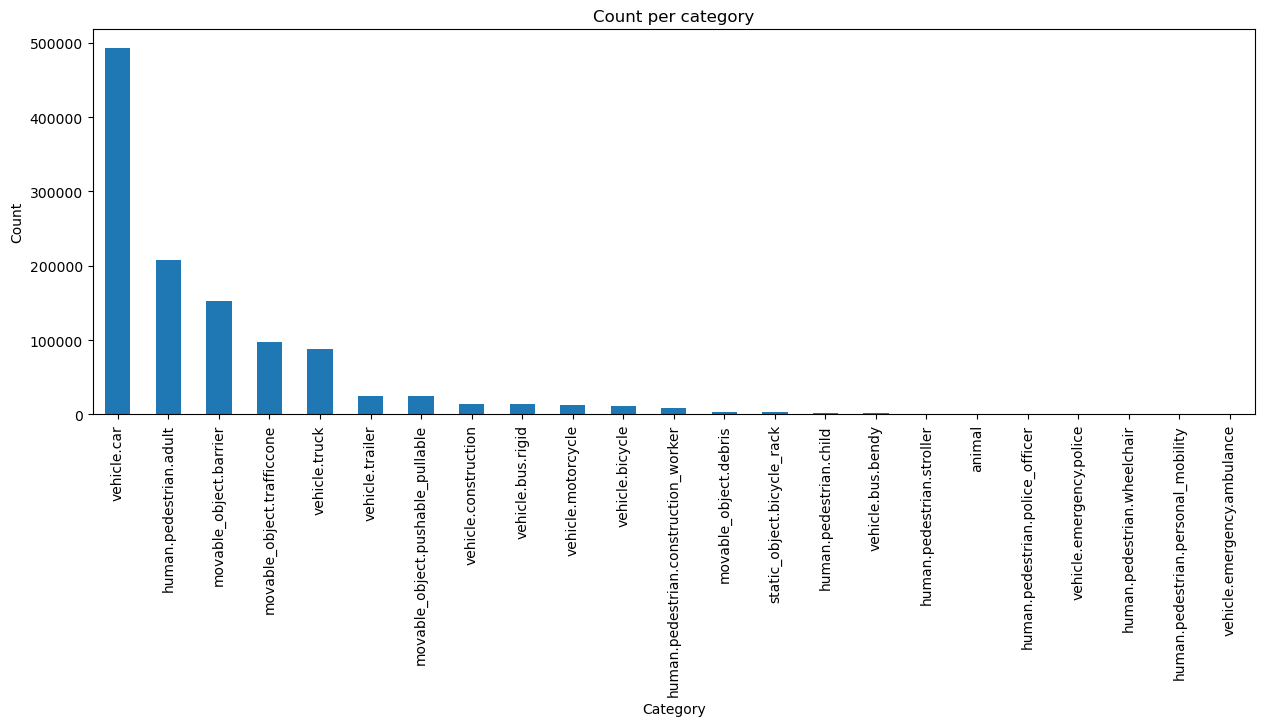

In [65]:
# ============================================================
# Annotation count by category
#
# Question answered:
# Which objects dominate the dataset?
# ============================================================

# number of objects by category_name
class_counts:pd.Series = raw_eda_df["category_name"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(15, 5))
class_counts.plot(kind="bar")
plt.title("Count per category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

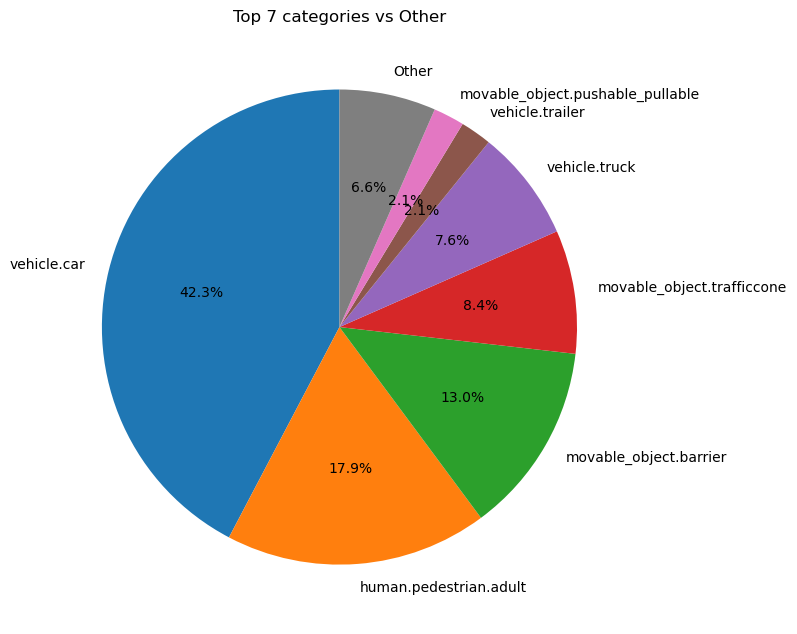


Categories included in 'Other':
category_name
vehicle.construction                    14671
vehicle.bus.rigid                       14501
vehicle.motorcycle                      12617
vehicle.bicycle                         11859
human.pedestrian.construction_worker     9161
movable_object.debris                    3016
static_object.bicycle_rack               2713
human.pedestrian.child                   2066
vehicle.bus.bendy                        1820
human.pedestrian.stroller                1072
animal                                    787
human.pedestrian.police_officer           727
vehicle.emergency.police                  638
human.pedestrian.wheelchair               503
human.pedestrian.personal_mobility        395
vehicle.emergency.ambulance                49
Name: count, dtype: int64


In [66]:
import matplotlib.pyplot as plt

class_counts = eda_df["category_name"].value_counts()

top_n = 7
top_counts = class_counts.iloc[:top_n]
other_count = class_counts.iloc[top_n:].sum()

pie_counts = top_counts.copy()
pie_counts["Other"] = other_count

excluded_categories = class_counts.iloc[top_n:]

plt.figure(figsize=(8, 8))
plt.pie(
    pie_counts.values,
    labels=pie_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(f"Top {top_n} categories vs Other")
plt.tight_layout()
plt.show()

print("\nCategories included in 'Other':")
print(excluded_categories)

**Note:**
* Category frequencies are not uniform, and some classes may be underrepresented.
* This class imbalance can affect the stability of class-wise statistical results.
* Therefore, a minimum count threshold of 30 annotations per class will be used when deciding whether a category is suitable for reliable statistical analysis.
 Categories below this threshold will be excluded from detailed class-level interpretation or clearly marked as low-support.

## Intrinsic object difficulty
To identify intrinsically difficult objects, I will check in this order:

* Rare classes
* Distance by class
* Volume and dimensions by class
* Visibility by class
* Projected box area by class
* Compound hard cases by class

### Object volume by category

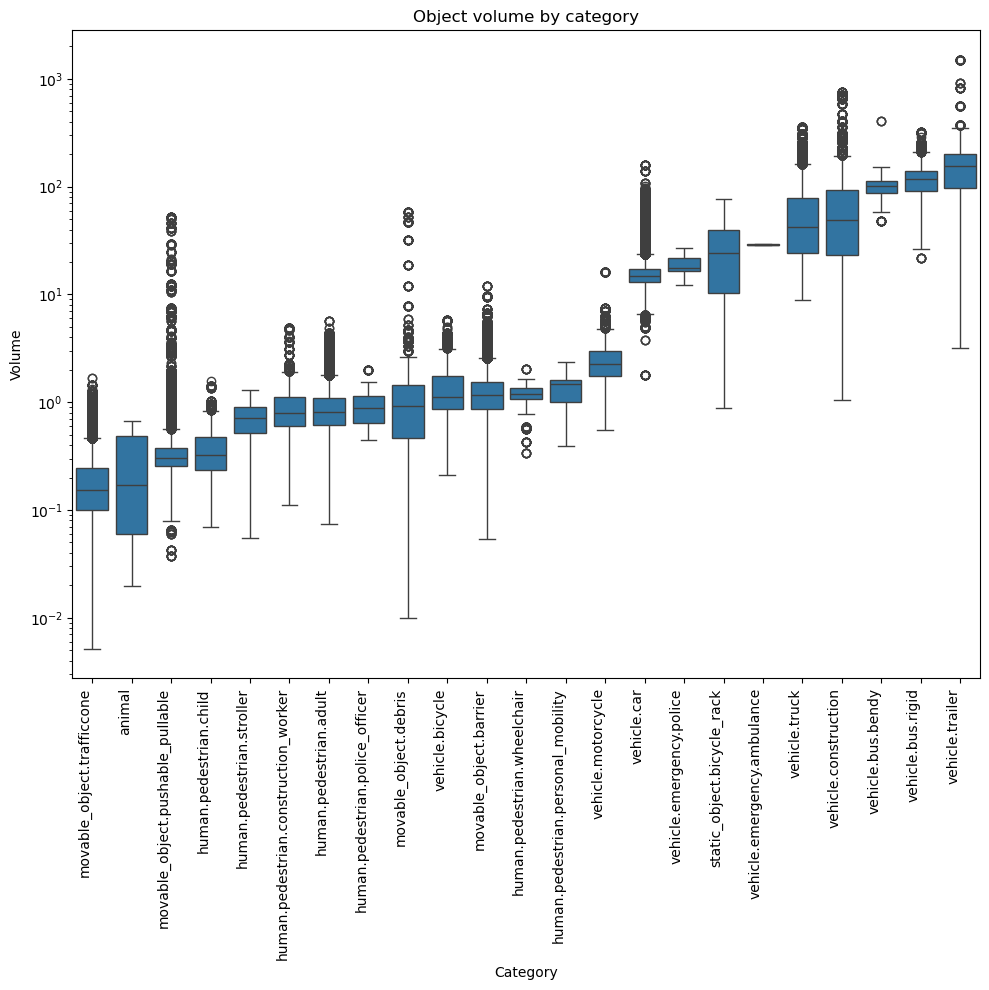

In [67]:
# ============================================================
# Object volume by category
#
# Question answered:
# Which categories are physically small or large?
# ============================================================

def plot_box_by_category(
    df: pd.DataFrame,
    y_col: str,
    title: str,
    ylabel: str,
    x_col: str = "category_name",
    figsize: tuple = (10,10),
    order_by_median: bool = True,
    log_scale: bool = False,
    show_fliers: bool = True,
    rotate_xticks: int = 90
) -> None:
    """Plot a boxplot of one numeric feature by category."""
    plot_df = df.dropna(subset=[x_col, y_col]).copy()

    order = None
    if order_by_median:
        order = (
            plot_df.groupby(x_col)[y_col]
            .median()
            .sort_values()
            .index
        )

    plt.figure(figsize=figsize)
    sns.boxplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        order=order,
        # showfliers=show_fliers # show outliers
    )

    plt.title(title)
    plt.xlabel("Category")
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate_xticks, ha="right")

    if log_scale:
        plt.yscale("log")

    plt.tight_layout()
    plt.show()   

plot_box_by_category(
    df=eda_df,
    y_col="volume",
    title="Object volume by category",
    ylabel="Volume",
    log_scale=True
)

**Note:**
* Object volume differs strongly across categories and spans multiple orders of magnitude.
* Small classes such as traffic cones and debris lie at the low end, while buses, trucks, and trailers lie at the high end.
* Some categories have tight size distributions, while others, especially large vehicles, show wider spread.
* This suggests that object volume is a useful feature for distinguishing broad category groups, though some mid-size classes still overlap.

In [68]:
def get_low_classes_by_median(
    df: pd.DataFrame,
    value_col: str,
    category_col: str = "category_name",
    threshold: float = 1.0
) -> pd.DataFrame:
    """Return classes whose median value is below the given threshold."""
    summary_df = (
        df.dropna(subset=[category_col, value_col])
        .groupby(category_col)[value_col]
        .median()
        .sort_values()
        .reset_index()
    )
    summary_df.columns = [category_col, f"median_{value_col}"]

    return summary_df.loc[summary_df[f"median_{value_col}"] < threshold].copy()

low_volume_df = get_low_classes_by_median(
    eda_df,
    value_col="volume",
    threshold=1.0
)
print(low_volume_df)

                          category_name  median_volume
0            movable_object.trafficcone       0.152942
1                                animal       0.169413
2      movable_object.pushable_pullable       0.300613
3                human.pedestrian.child       0.324830
4             human.pedestrian.stroller       0.715726
5  human.pedestrian.construction_worker       0.796781
6                human.pedestrian.adult       0.810455
7       human.pedestrian.police_officer       0.882394
8                 movable_object.debris       0.923709


### Object aspectio ratio by category

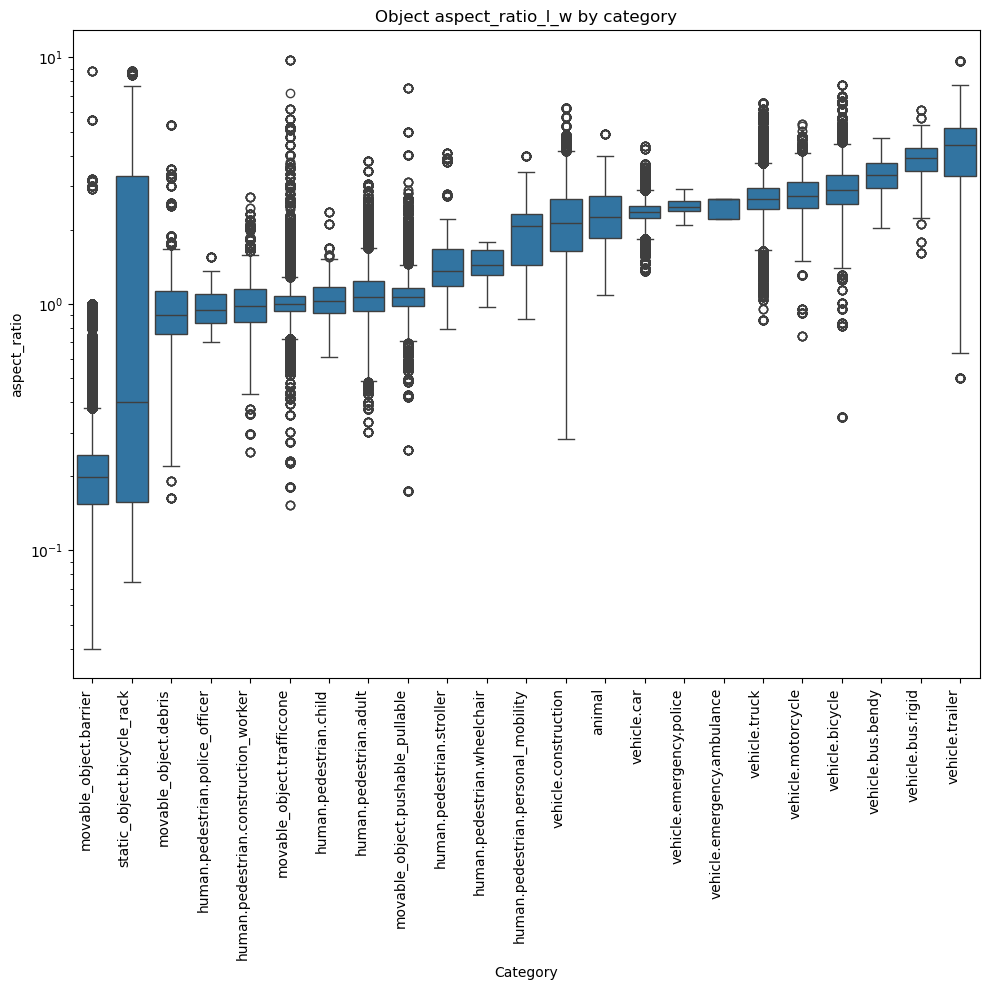

In [69]:
# ============================================================
# Object volume by aspect ratio
#
# Question answered:
# Which categories have small or large aspect ratio?
# ============================================================

plot_box_by_category(
    df=eda_df,
    y_col="aspect_ratio_l_w",
    title="Object aspect_ratio_l_w by category",
    ylabel="aspect_ratio",
    log_scale=True
)

In [70]:
low_aspect_ratio_df = get_low_classes_by_median(
    eda_df,
    value_col="aspect_ratio_l_w",
    threshold=1.0
)
print(low_volume_df)

                          category_name  median_volume
0            movable_object.trafficcone       0.152942
1                                animal       0.169413
2      movable_object.pushable_pullable       0.300613
3                human.pedestrian.child       0.324830
4             human.pedestrian.stroller       0.715726
5  human.pedestrian.construction_worker       0.796781
6                human.pedestrian.adult       0.810455
7       human.pedestrian.police_officer       0.882394
8                 movable_object.debris       0.923709


### Object visibility by category

In [71]:
# ============================================================
# Object visibility by category
#
# Question answered:
# Which categories are poorly visible?
# ============================================================

vis_by_class = (
    pd.crosstab(
        index = eda_df["category_name"],
        columns = eda_df["visibility_level"],
        normalize="index",
    )
    .sort_values("v0-40")
)

vis_by_class


visibility_level,v0-40,v40-60,v60-80,v80-100
category_name,,,,
vehicle.emergency.ambulance,0.040816,0.020408,0.000000,0.938776
human.pedestrian.wheelchair,0.105368,0.063618,0.093439,0.737575
human.pedestrian.personal_mobility,0.106329,0.118987,0.263291,0.511392
vehicle.bus.rigid,0.151576,0.107510,0.172402,0.568513
movable_object.debris,0.161141,0.053382,0.098475,0.687003
movable_object.trafficcone,0.183699,0.045233,0.067538,0.703529
animal,0.217281,0.072427,0.074968,0.635324
human.pedestrian.police_officer,0.220083,0.059147,0.097662,0.623109
static_object.bicycle_rack,0.239587,0.121637,0.135643,0.503133


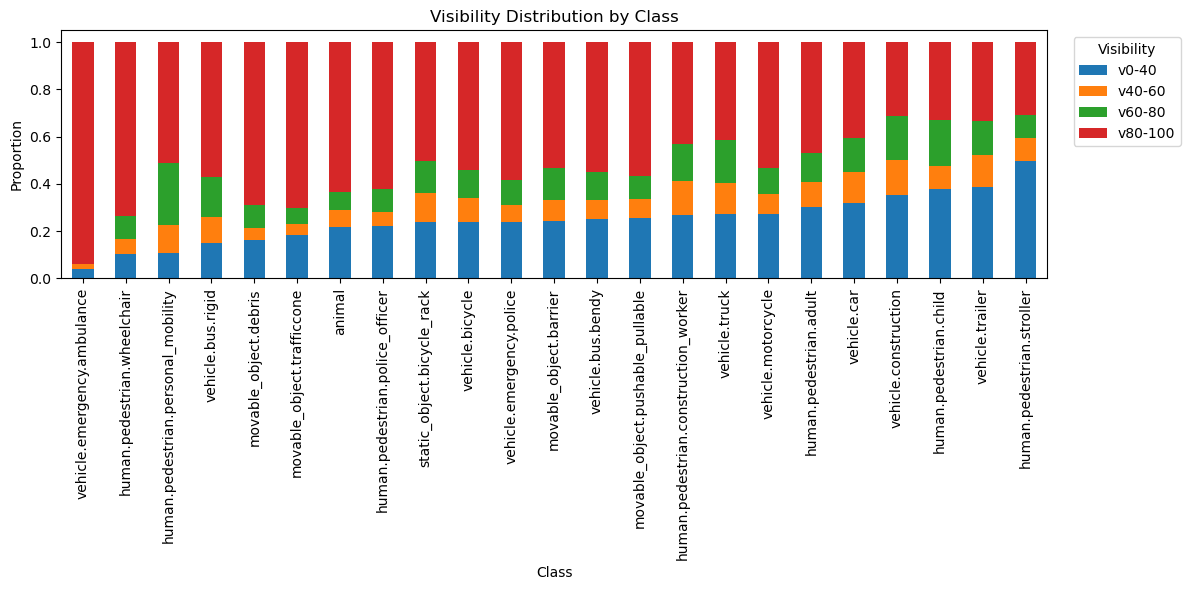

In [72]:
vis_by_class.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Visibility Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Proportion")
plt.legend(title="Visibility", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [73]:
low_visibility_df = vis_by_class[vis_by_class["v0-40"]>0.25].copy()
low_visibility_df

visibility_level,v0-40,v40-60,v60-80,v80-100
category_name,,,,
vehicle.bus.bendy,0.250549,0.082967,0.116484,0.550000
movable_object.pushable_pullable,0.256858,0.079212,0.099533,0.564397
human.pedestrian.construction_worker,0.267220,0.146600,0.155878,0.430302
vehicle.truck,0.271298,0.134265,0.180504,0.413934
vehicle.motorcycle,0.273678,0.081715,0.111675,0.532932
human.pedestrian.adult,0.301138,0.108375,0.120496,0.469991
vehicle.car,0.320126,0.130128,0.142894,0.406852
vehicle.construction,0.353759,0.146820,0.186695,0.312726
human.pedestrian.child,0.378025,0.097289,0.195547,0.329138


### Hard categories summary

In [74]:
low_visibility_set = set(low_visibility_df.index)
low_aspect_ratio_set = set(low_aspect_ratio_df["category_name"])
low_volume_set = set(low_volume_df["category_name"])

In [75]:
hard_in_all_three = (
    low_visibility_set
    & low_aspect_ratio_set
    & low_volume_set
)

print("\n Hard in all three:")
pprint(hard_in_all_three)

hard_in_at_least_two = (
    (low_visibility_set & low_aspect_ratio_set)
    | (low_visibility_set & low_volume_set)
    | (low_aspect_ratio_set & low_volume_set)
)

print("\n Hard in at least two:")
pprint(hard_in_at_least_two)


 Hard in all three:
{'human.pedestrian.construction_worker'}

 Hard in at least two:
{'human.pedestrian.adult',
 'human.pedestrian.child',
 'human.pedestrian.construction_worker',
 'human.pedestrian.police_officer',
 'human.pedestrian.stroller',
 'movable_object.debris',
 'movable_object.pushable_pullable'}


In [76]:
print("Low visibility + low aspect ratio:")
print(low_visibility_set & low_aspect_ratio_set)

print("\nLow visibility + low volume:")
print(low_visibility_set & low_volume_set)

print("\nLow aspect ratio + low volume:")
print(low_aspect_ratio_set & low_volume_set)

Low visibility + low aspect ratio:
{'human.pedestrian.construction_worker'}

Low visibility + low volume:
{'human.pedestrian.stroller', 'human.pedestrian.adult', 'human.pedestrian.construction_worker', 'human.pedestrian.child', 'movable_object.pushable_pullable'}

Low aspect ratio + low volume:
{'movable_object.debris', 'human.pedestrian.construction_worker', 'human.pedestrian.police_officer'}


In [77]:
hard_rows = eda_df[eda_df["category_name"].isin(hard_in_at_least_two)].shape[0]
all_rows = eda_df.shape[0]

print("All intrinsic hard categories:\n",hard_in_at_least_two)
print("\nPercentage of rows from hard categories:", hard_rows / all_rows * 100)

All intrinsic hard categories:
 {'human.pedestrian.stroller', 'human.pedestrian.adult', 'movable_object.pushable_pullable', 'movable_object.debris', 'human.pedestrian.construction_worker', 'human.pedestrian.police_officer', 'human.pedestrian.child'}

Percentage of rows from hard categories: 21.341946017233944


### Observations

This section should answer:

which categories are inherently hard because of geometry or visibility
whether those hard categories are marginal or substantial in the dataset
Example key insights
Example 1

Some categories are intrinsically difficult because they combine small physical size, unfavorable shape, and lower visibility, making them challenging independently of sensor support.

Example 2

Intrinsic difficulty is not evenly distributed across classes: a small subset of categories accounts for a large share of the most difficult objects.

Example 3

Categories such as traffic cones, barriers, or pedestrians may appear difficult not only because of scene conditions, but because their geometry and visibility characteristics are already unfavorable.

Example 4

Since intrinsically hard categories cover a substantial fraction of dataset rows, later sensor-regime analysis should not treat them as rare corner cases.

Strong concluding sentence template

Overall, intrinsic difficulty is concentrated in a small number of categories whose object size, shape, and visibility make them systematically harder to detect, suggesting that later fusion analysis should pay particular attention to these classes.

 ## Sensor reliability by regime
This section characterizes the reliability of each sensing modality across distance and visibility regimes, in order to identify where each sensor is informative, weak, or missing before analyzing fusion complementarity.

### Camera reliability by distance

In [78]:
def summarize_flag_by_group(df, group_col, flag_col, sort_index=True):
    table = (
        pd.crosstab(
            index=df[group_col],
            columns=df[flag_col],
            normalize="index"
        )
    )

    if sort_index:
        table = table.sort_index()

    return table

cam_weak_by_distance = summarize_flag_by_group(eda_df, "distance_bin", "weak_camera_view")
cam_limited_by_distance = summarize_flag_by_group(eda_df, "distance_bin", "limited_camera_view")
cam_good_by_distance = summarize_flag_by_group(eda_df, "distance_bin", "good_camera_view")

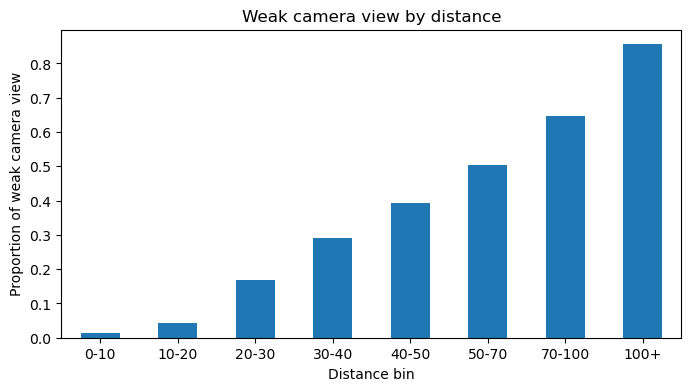

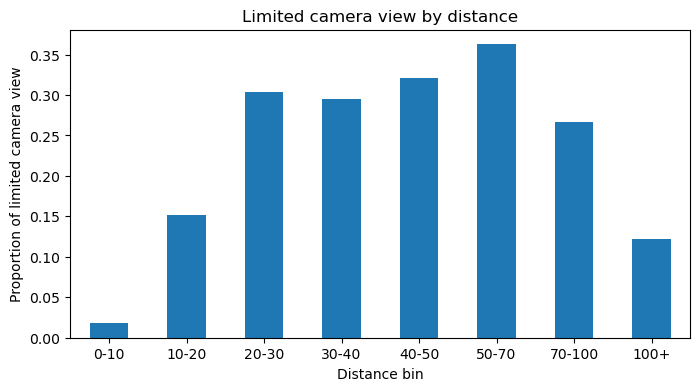

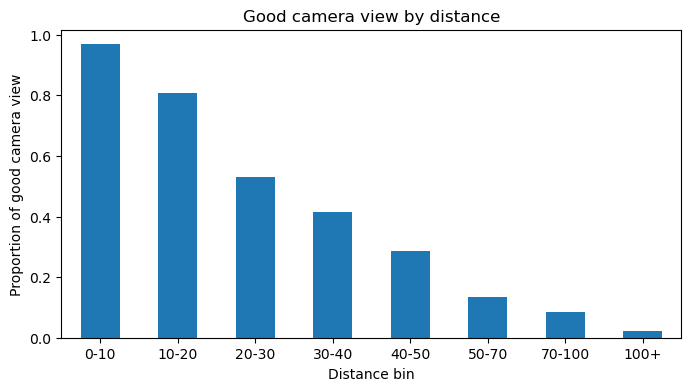

In [79]:
def plot_bar_from_table(
    table,
    column=None,
    title="",
    ylabel="",
    xlabel="",
    figsize=(8, 4),
    rot=0,
    ha="center"
):
    """
    Plot a bar chart from a pandas Series or DataFrame.

    """
    if column is not None:
        ax = table[column].plot.bar(figsize=figsize, title=title, rot=rot)
    else:
        ax = table.plot.bar(figsize=figsize, title=title, rot=rot)

    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=rot, ha=ha)
    plt.show()

    return None

camera_flags = {
    "weak_camera_view": "Weak camera view",
    "limited_camera_view": "Limited camera view",
    "good_camera_view": "Good camera view"
}

for flag, label in camera_flags.items():
    table = summarize_flag_by_group(eda_df, "distance_bin", flag)
    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin"
    )

### Camera reliability by visibility

In [80]:
cam_weak_by_visibility = summarize_flag_by_group(eda_df, "visibility_level", "weak_camera_view")
cam_limited_by_visibility = summarize_flag_by_group(eda_df, "visibility_level", "limited_camera_view")
cam_good_by_visibility = summarize_flag_by_group(eda_df, "visibility_level", "good_camera_view")

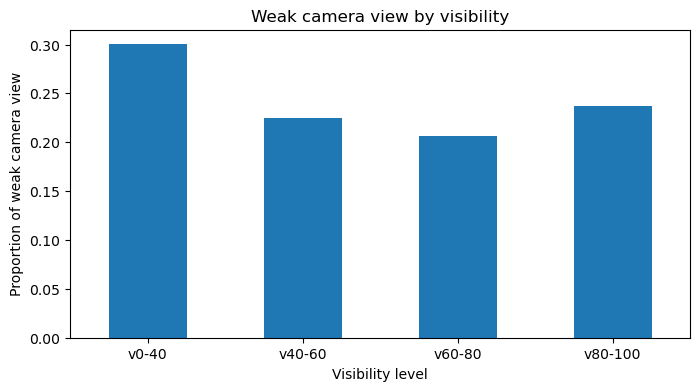

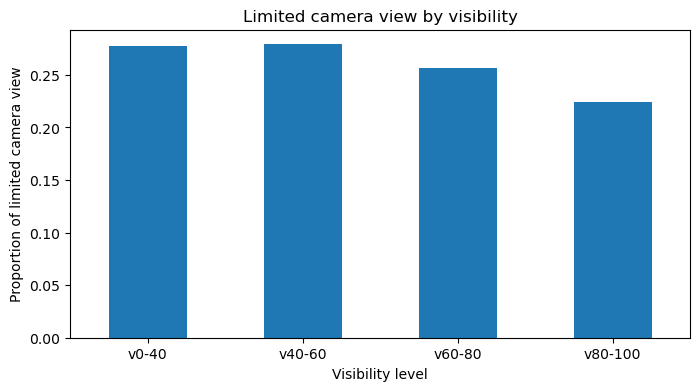

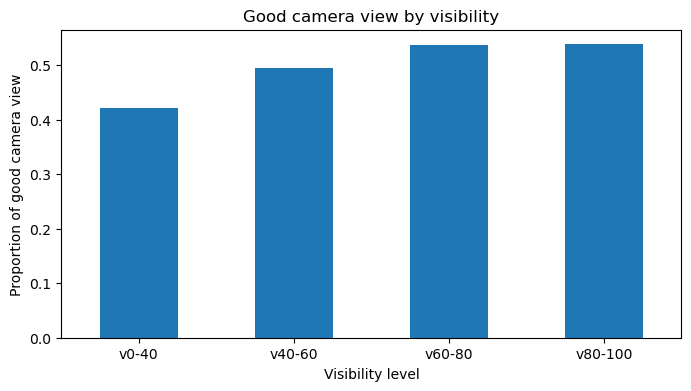

In [83]:
for flag, label in camera_flags.items():
    table = summarize_flag_by_group(eda_df, "visibility_level", flag)
    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level"
    )


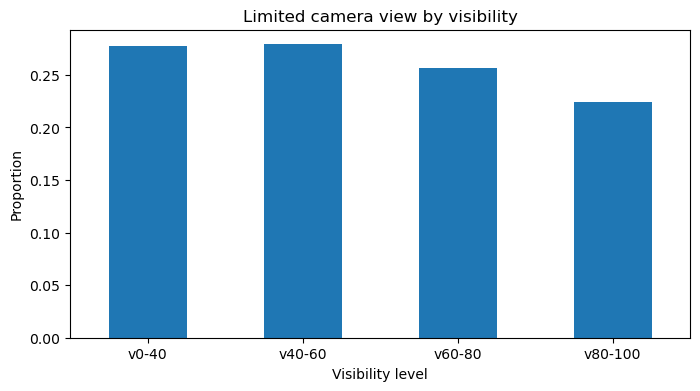

In [82]:
plot_bar_from_table(
    table=cam_limited_by_visibility,
    column=True,
    title="Limited camera view by visibility",
    ylabel="Proportion",
    xlabel="Visibility level"
)

### Camera reliability by category

In [84]:
cam_good_by_category = summarize_flag_by_group(eda_df, "category_name", "good_camera_view", sort_index=False)
cam_good_by_category_sorted = cam_good_by_category.sort_values(by=True, ascending=False)

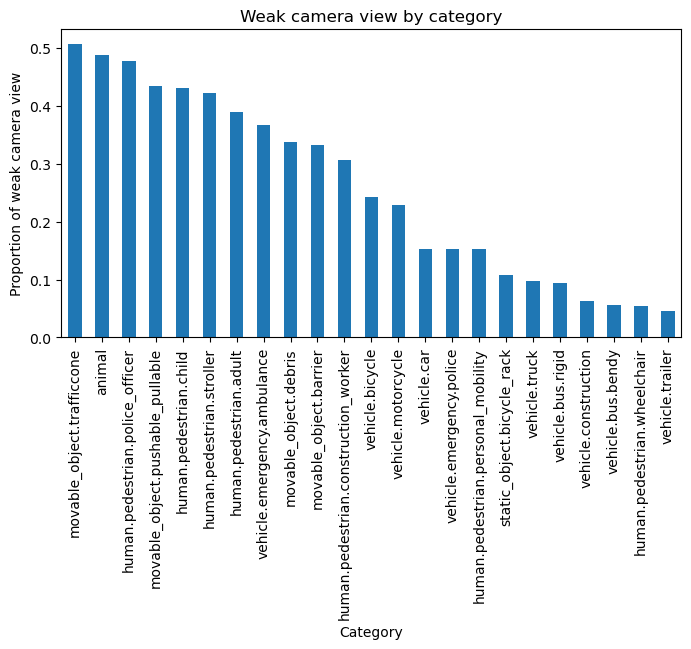

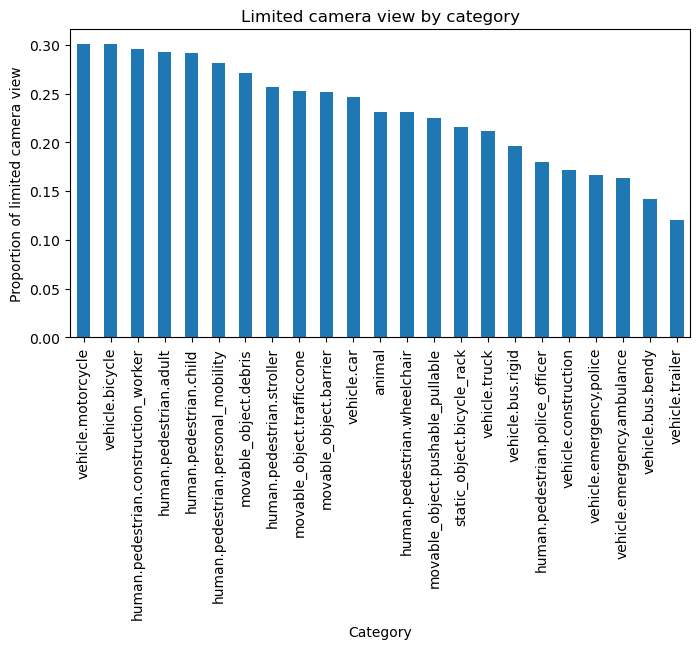

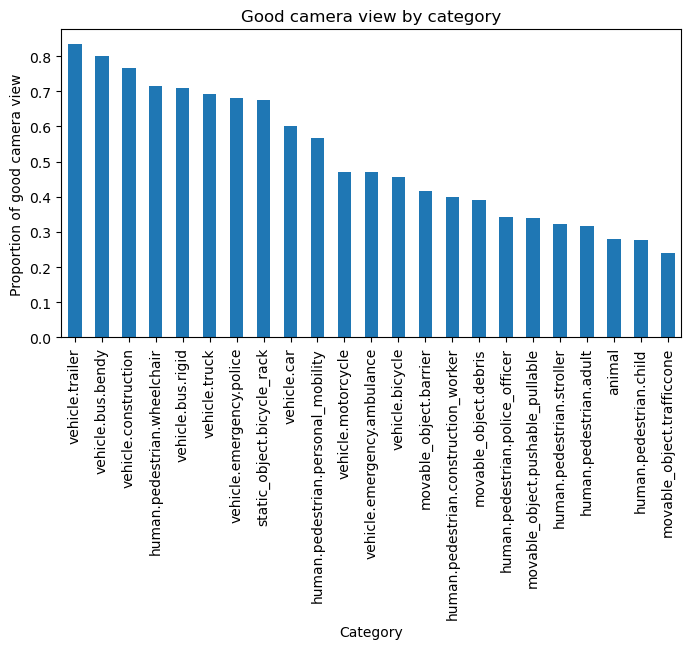

In [85]:
for flag, label in camera_flags.items():
    table = summarize_flag_by_group(eda_df, "category_name", flag, sort_index=False)
    table = table.sort_values(by=True, ascending=False)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by category",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Category",
        rot=90
    )

### Camera summary table

In [86]:
camera_flags = {
    "weak_camera_view": "Weak camera view",
    "limited_camera_view": "Limited camera view",
    "good_camera_view": "Good camera view"
}


In [87]:
camera_support_summary_by_distance = (
    eda_df.groupby("distance_bin")[
        ["weak_camera_view", "limited_camera_view", "good_camera_view"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(camera_support_summary_by_distance)

              weak_camera_view  limited_camera_view  good_camera_view
distance_bin                                                         
0-10                       1.4                  1.8              96.8
10-20                      4.2                 15.2              80.6
20-30                     16.7                 30.3              53.0
30-40                     29.0                 29.5              41.5
40-50                     39.2                 32.1              28.7
50-70                     50.2                 36.3              13.5
70-100                    64.8                 26.7               8.5
100+                      85.5                 12.2               2.2


In [88]:
camera_support_summary_by_distance = (
    eda_df.groupby("visibility_level")[
        ["weak_camera_view", "limited_camera_view", "good_camera_view"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(camera_support_summary_by_distance)

                  weak_camera_view  limited_camera_view  good_camera_view
visibility_level                                                         
v0-40                         30.0                 27.8              42.2
v40-60                        22.5                 27.9              49.6
v60-80                        20.7                 25.7              53.7
v80-100                       23.7                 22.4              53.8


### LiDAR reliability by distance

In [89]:
lidar_flags = {
    "no_lidar_support": "No LiDAR support",
    "low_lidar_support": "Low LiDAR support",
    "usable_lidar_support": "Usable LiDAR support"
}

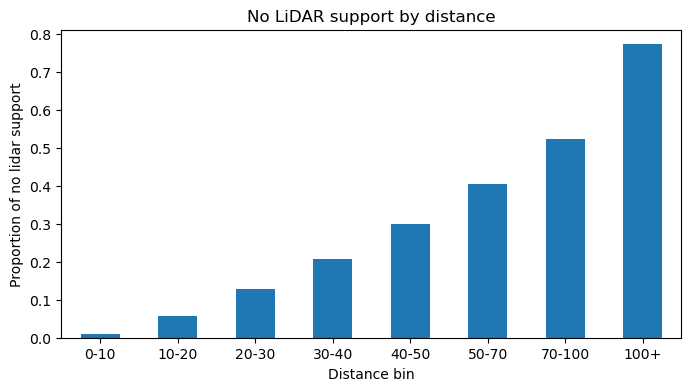

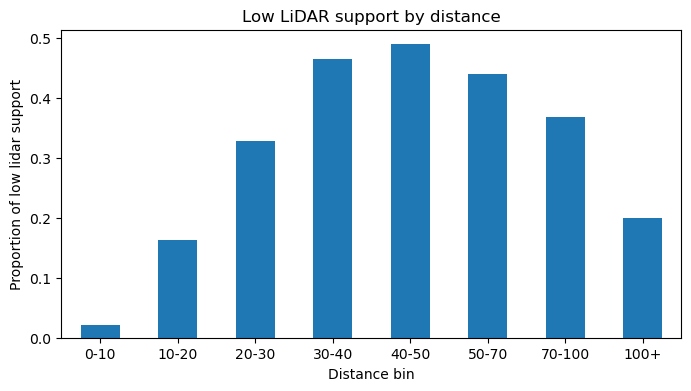

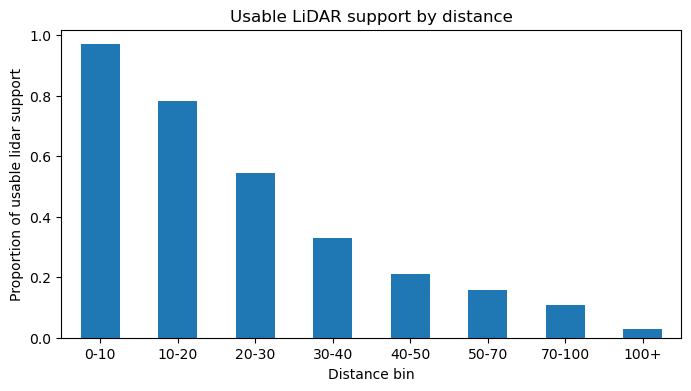

In [90]:
for flag, label in lidar_flags.items():
    table = summarize_flag_by_group(eda_df, "distance_bin", flag)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin"
    )

### LiDAR reliability by visibility

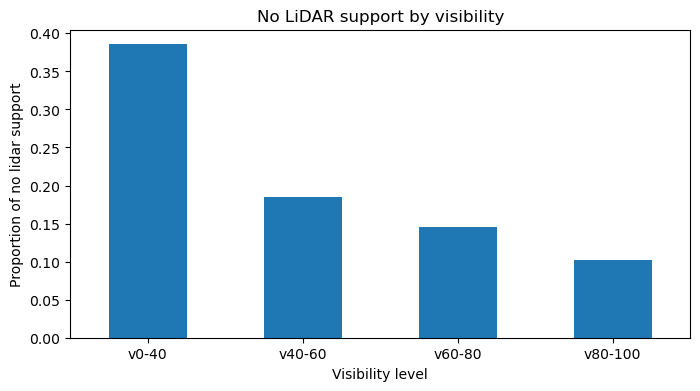

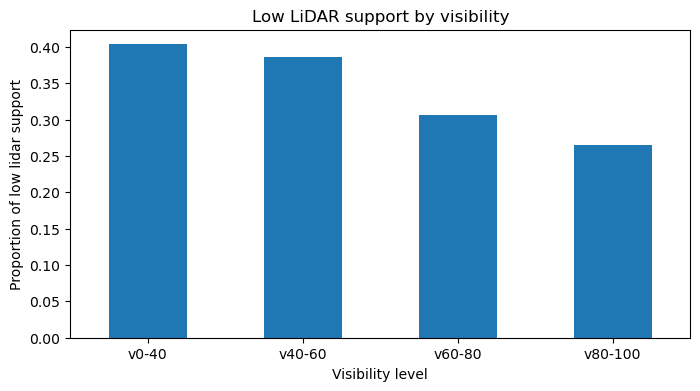

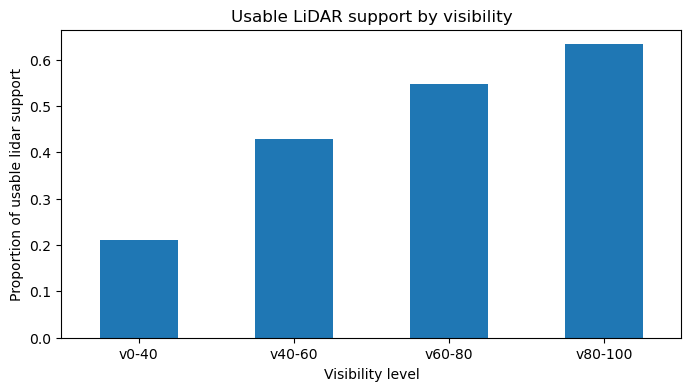

In [91]:
for flag, label in lidar_flags.items():
    table = summarize_flag_by_group(eda_df, "visibility_level", flag)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level"
    )

LiDAR reliability by category

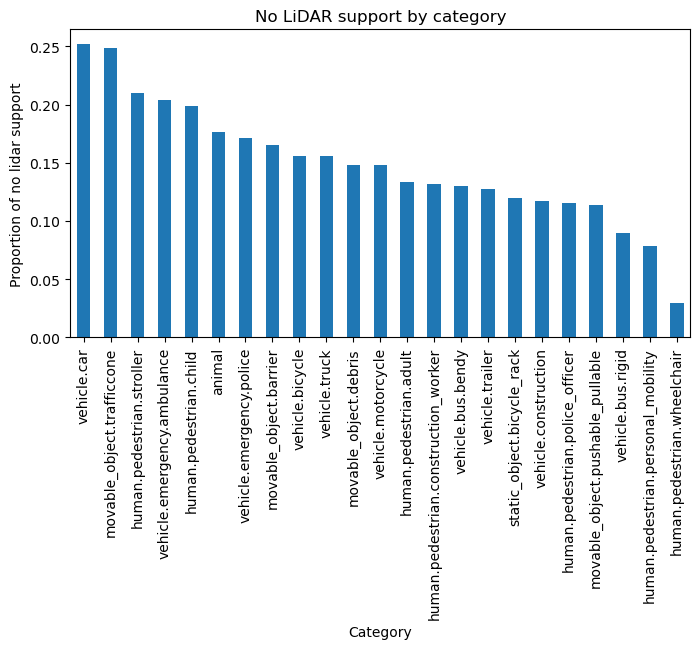

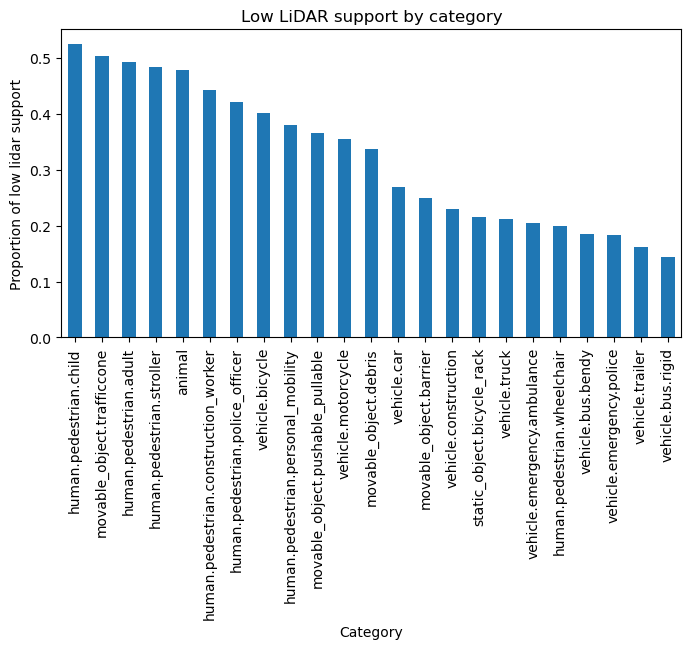

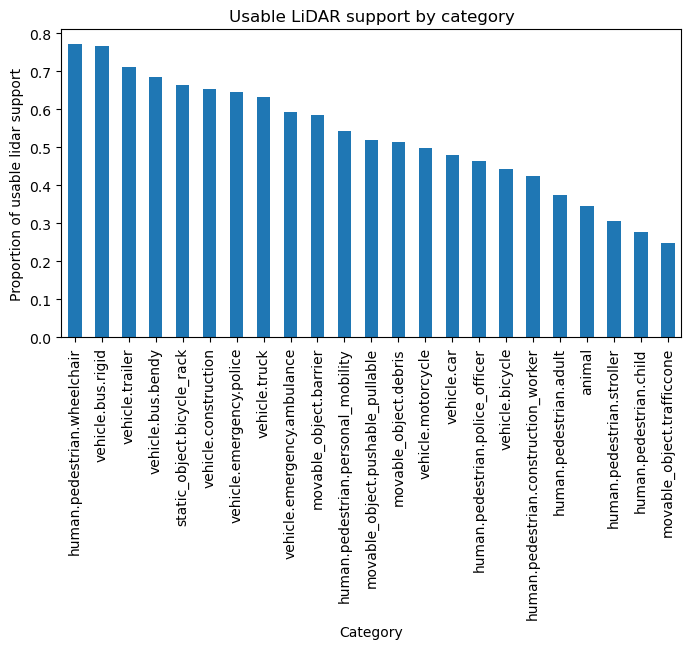

In [92]:
for flag, label in lidar_flags.items():
    table = summarize_flag_by_group(
        eda_df, "category_name", flag, sort_index=False
    )

    table = table.sort_values(by=True, ascending=False)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by category",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Category",
        rot=90
    )

### LiDAR summary table

In [93]:
lidar_support_summary_by_distance = (
    eda_df.groupby("distance_bin")[
        ["no_lidar_support", "low_lidar_support", "usable_lidar_support"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(lidar_support_summary_by_distance)

              no_lidar_support  low_lidar_support  usable_lidar_support
distance_bin                                                           
0-10                       0.9                2.2                  96.9
10-20                      5.6               16.3                  78.1
20-30                     12.8               32.8                  54.5
30-40                     20.7               46.5                  32.8
40-50                     29.9               48.9                  21.2
50-70                     40.3               44.0                  15.7
70-100                    52.3               36.8                  10.9
100+                      77.2               19.9                   2.9


In [94]:
lidar_support_summary_by_visibility = (
    eda_df.groupby("visibility_level")[
        ["no_lidar_support", "low_lidar_support", "usable_lidar_support"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(lidar_support_summary_by_visibility)

                  no_lidar_support  low_lidar_support  usable_lidar_support
visibility_level                                                           
v0-40                         38.6               40.3                  21.1
v40-60                        18.5               38.7                  42.9
v60-80                        14.5               30.7                  54.8
v80-100                       10.2               26.6                  63.3


In [95]:
# ============================================================
# LiDAR support by factor
#
# Question answered:
# When does LiDAR become sparse?
# ============================================================
lidar_low_by_distance = (
    pd.crosstab(
        index=eda_df["distance_bin"],
        columns=eda_df["low_lidar_support"],
        normalize="index",
    )
    .sort_index()
)

lidar_low_by_distance

low_lidar_support,False,True
distance_bin,,
0-10,0.978060,0.021940
10-20,0.836622,0.163378
20-30,0.672419,0.327581
30-40,0.535325,0.464675
40-50,0.510507,0.489493
50-70,0.560202,0.439798
70-100,0.631620,0.368380
100+,0.800756,0.199244


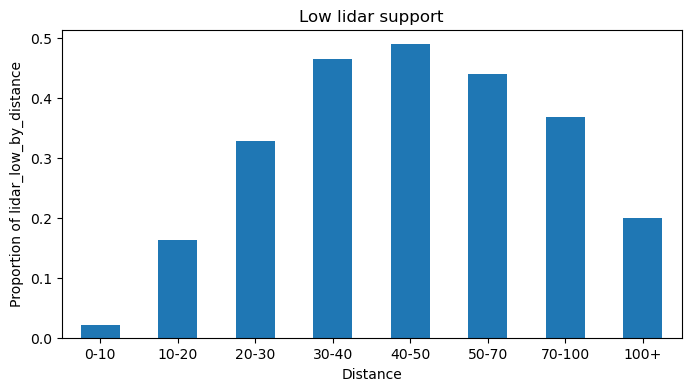

In [96]:
plot_bar_from_table(
    table=lidar_low_by_distance,
    column=True,
    title="Low lidar support",
    ylabel="Proportion of lidar_low_by_distance",
    xlabel="Distance"
)

In [97]:
usable_lidar_support = (
    pd.crosstab(
        index=eda_df["category_name"],
        columns=eda_df["low_lidar_support"],
        normalize="index",
    )
    .sort_index()
)

usable_lidar_support_sorted = usable_lidar_support.sort_values(True).copy()
usable_lidar_support_sorted 

low_lidar_support,False,True
category_name,,
vehicle.bus.rigid,0.856286,0.143714
vehicle.trailer,0.838576,0.161424
vehicle.emergency.police,0.816614,0.183386
vehicle.bus.bendy,0.815385,0.184615
human.pedestrian.wheelchair,0.801193,0.198807
vehicle.emergency.ambulance,0.795918,0.204082
vehicle.truck,0.787492,0.212508
static_object.bicycle_rack,0.784003,0.215997
vehicle.construction,0.769341,0.230659


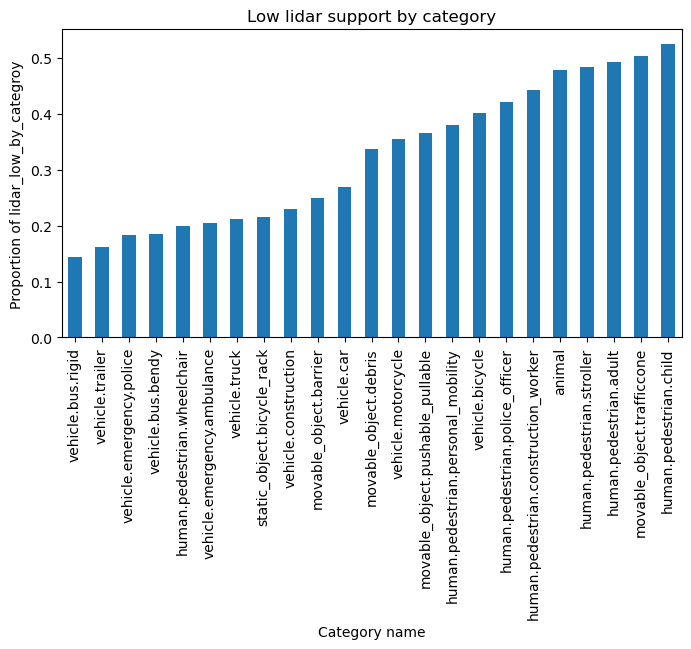

In [98]:
plot_bar_from_table(
    table=usable_lidar_support_sorted,
    column=True,
    title="Low lidar support by category",
    ylabel="Proportion of lidar_low_by_categroy",
    xlabel="Category name",
    rot=90
)

**Note**:

LiDAR struggles with small, thin, and irregular objects, but performs reliably on large, solid objects.

### Radar reliability by distance

In [99]:
radar_flags = {
    "no_radar_support": "No radar support",
    "low_radar_support": "Low radar support",
    "usable_radar_support": "Usable radar support",
    "usable_radar_support": "Radar present"
}

In [100]:
radar_present_by_distance = summarize_flag_by_group(
    eda_df, "distance_bin", "usable_radar_support"
)

radar_none_by_distance = summarize_flag_by_group(
    eda_df, "distance_bin", "no_radar_support"
)

radar_low_by_distance = summarize_flag_by_group(
    eda_df, "distance_bin", "low_radar_support"
)

radar_usable_by_distance = summarize_flag_by_group(
    eda_df, "distance_bin", "usable_radar_support"
)

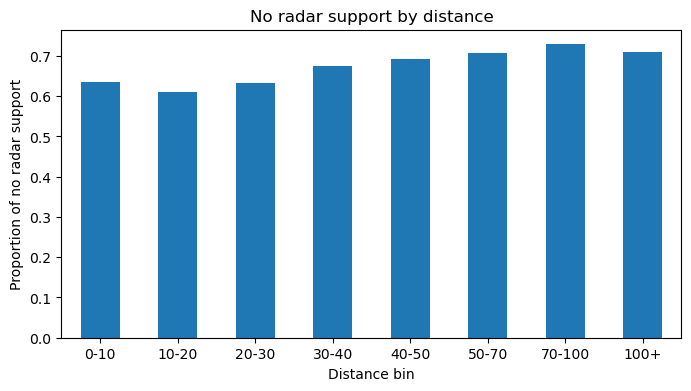

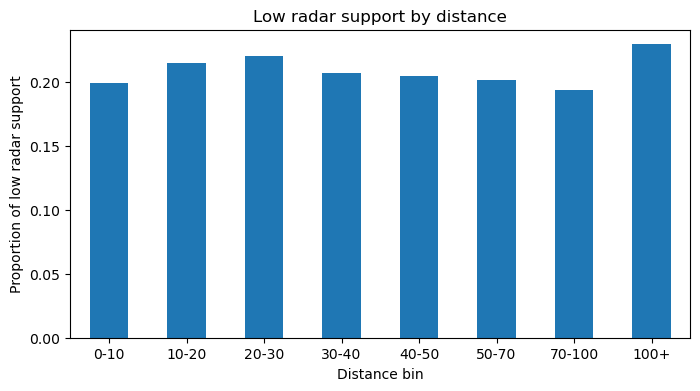

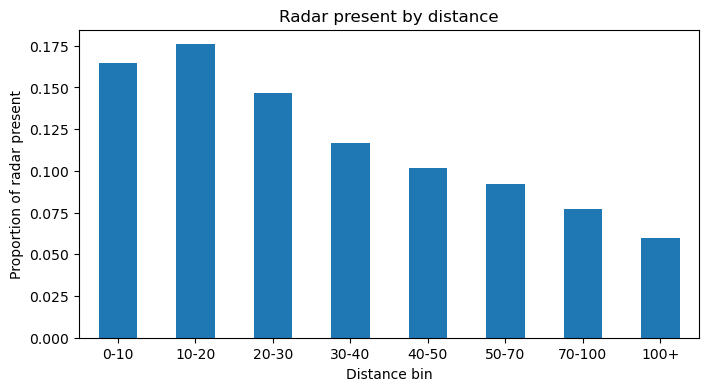

In [101]:
for flag, label in radar_flags.items():
    table = summarize_flag_by_group(eda_df, "distance_bin", flag)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by distance",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Distance bin"
    )

### Radar reliability by visibility

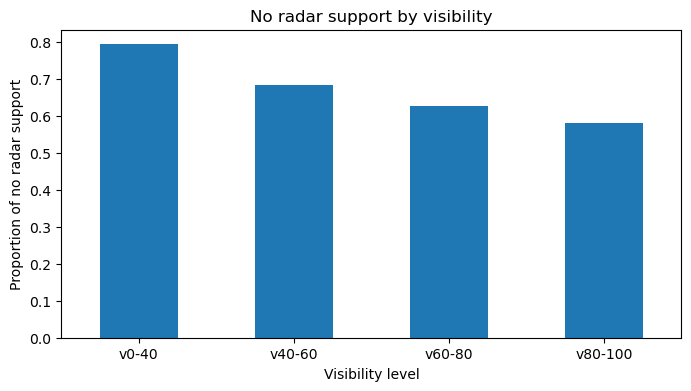

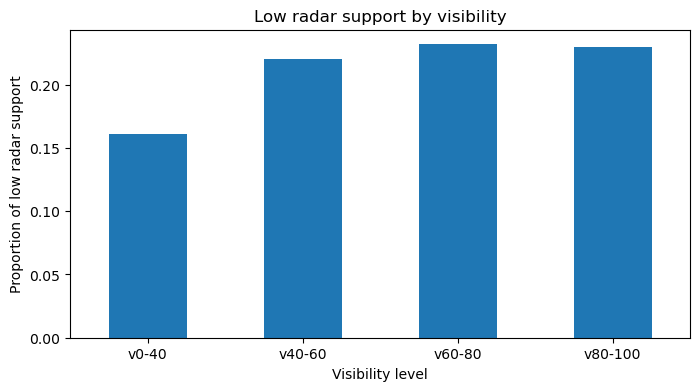

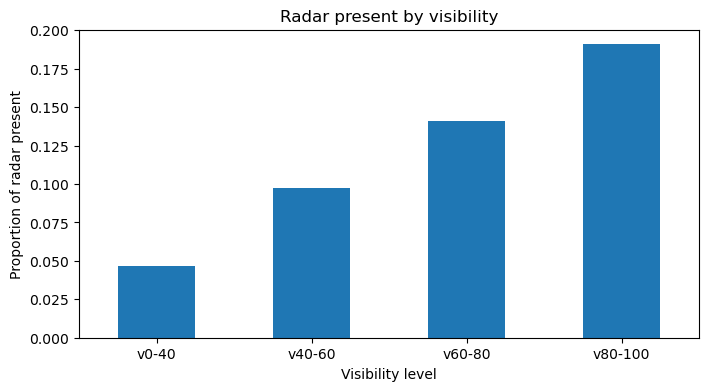

In [102]:
for flag, label in radar_flags.items():
    table = summarize_flag_by_group(eda_df, "visibility_level", flag)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by visibility",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Visibility level"
    )

### Radar reliability by category

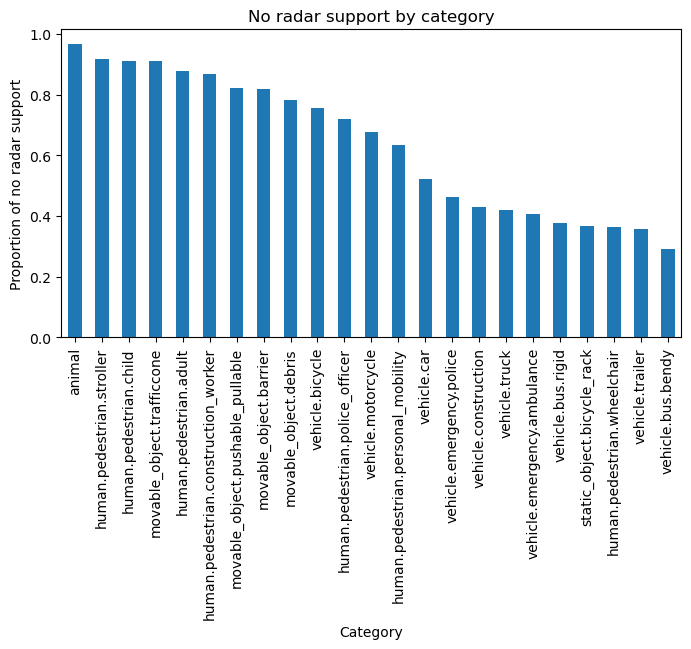

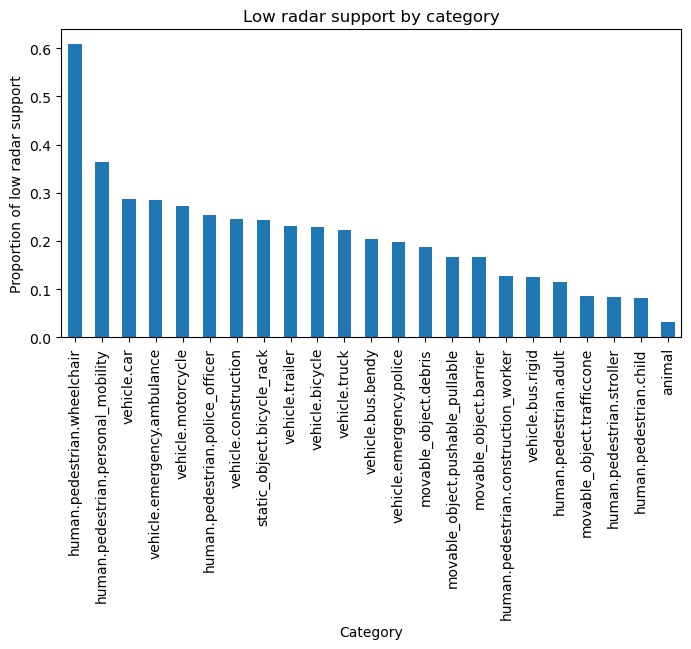

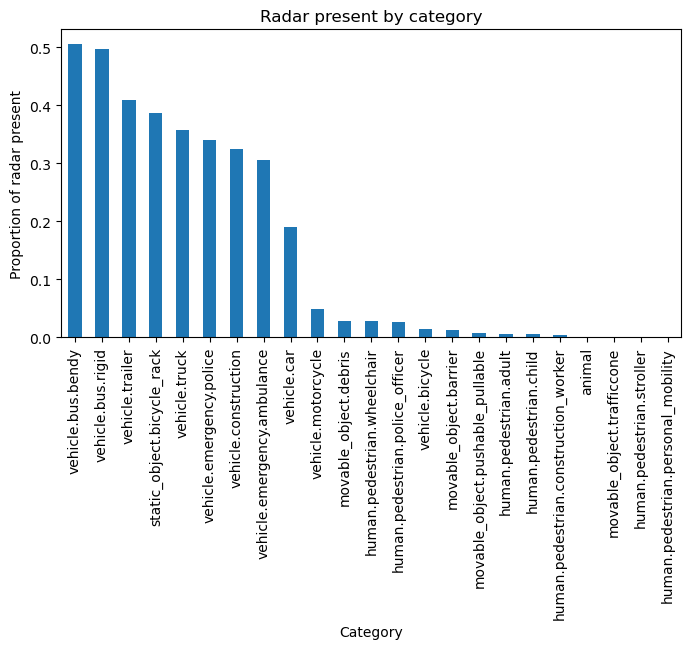

In [103]:
for flag, label in radar_flags.items():
    table = summarize_flag_by_group(
        eda_df, "category_name", flag, sort_index=False
    ).sort_values(by=True, ascending=False)

    plot_bar_from_table(
        table=table,
        column=True,
        title=f"{label} by category",
        ylabel=f"Proportion of {label.lower()}",
        xlabel="Category",
        rot=90
    )

### Radar summary table

In [104]:
radar_support_summary_by_distance = (
    eda_df.groupby("distance_bin")[
        ["no_radar_support", "low_radar_support", "usable_radar_support"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(radar_support_summary_by_distance)

              no_radar_support  low_radar_support  usable_radar_support
distance_bin                                                           
0-10                      63.6               19.9                  16.5
10-20                     60.9               21.5                  17.6
20-30                     63.3               22.0                  14.7
30-40                     67.6               20.7                  11.7
40-50                     69.4               20.5                  10.1
50-70                     70.6               20.2                   9.2
70-100                    72.9               19.4                   7.7
100+                      71.1               23.0                   5.9


In [105]:
radar_support_summary_by_visibility = (
    eda_df.groupby("visibility_level")[
        ["no_radar_support", "low_radar_support", "usable_radar_support", "usable_radar_support"]
    ]
    .mean()
    .mul(100)
    .round(1)
)

print(radar_support_summary_by_visibility)

                  no_radar_support  low_radar_support  usable_radar_support  \
visibility_level                                                              
v0-40                         79.3               16.1                   4.7   
v40-60                        68.2               22.0                   9.7   
v60-80                        62.7               23.2                  14.1   
v80-100                       57.9               23.0                  19.1   

                  usable_radar_support  
visibility_level                        
v0-40                              4.7  
v40-60                             9.7  
v60-80                            14.1  
v80-100                           19.1  


In [106]:
# ============================================================
# Radar support by factor
#
# Question answered:
# When is radar meaningfully present?
# ============================================================
radar_present_by_distance = (
    pd.crosstab(
        index=eda_df["distance_bin"],
        columns=eda_df["usable_radar_support"],
        normalize="index",
    )
    .sort_index()
)

radar_present_by_distance

usable_radar_support,False,True
distance_bin,,
0-10,0.835063,0.164937
10-20,0.824196,0.175804
20-30,0.853370,0.146630
30-40,0.883391,0.116609
40-50,0.898574,0.101426
50-70,0.908169,0.091831
70-100,0.922785,0.077215
100+,0.940503,0.059497


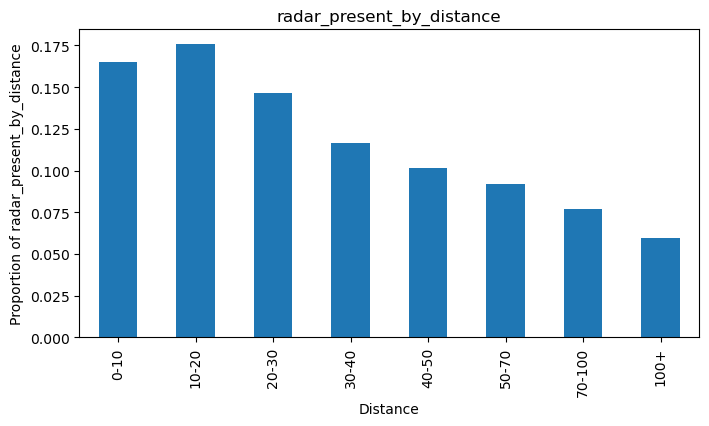

In [107]:
plot_bar_from_table(
    table=radar_present_by_distance,
    column=True,
    title="radar_present_by_distance",
    ylabel="Proportion of radar_present_by_distance",
    xlabel="Distance",
    rot=90
)

In [108]:
radar_present_by_class = (
    pd.crosstab(
        index=eda_df["category_name"],
        columns=eda_df["usable_radar_support"],
        normalize="index",
    )
    .sort_index()
)

radar_present_by_class_sorted = radar_present_by_class.sort_values(True).copy()

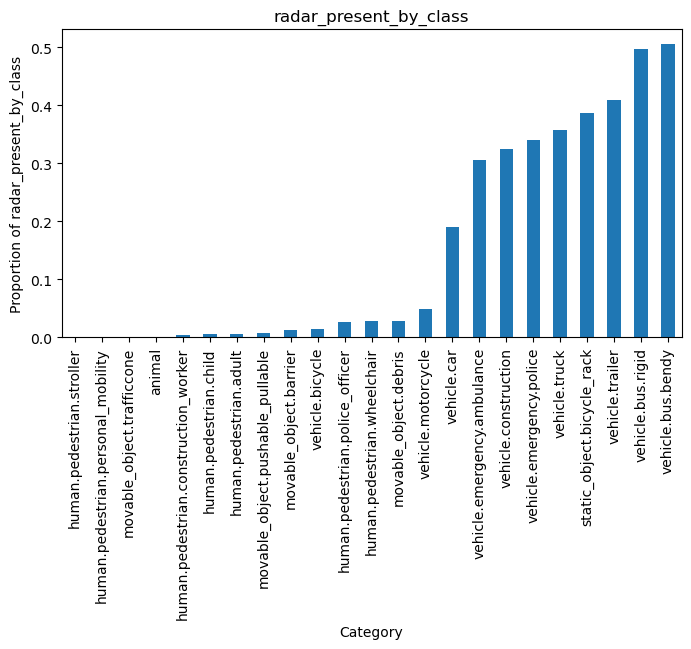

In [109]:
plot_bar_from_table(
    table=radar_present_by_class_sorted,
    column=True,
    title="radar_present_by_class",
    ylabel="Proportion of radar_present_by_class",
    xlabel="Category",
    rot=90
)

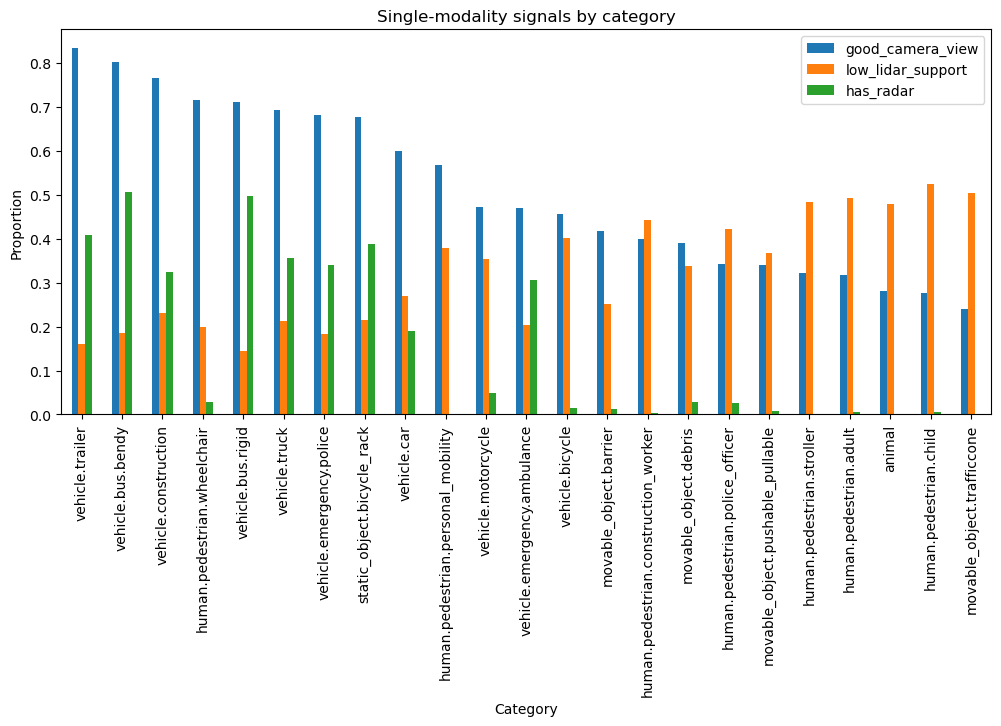

In [110]:
# ============================================================
# Combine camera, LiDAR, and radar category rates in one plot
# ============================================================

modality_by_category = pd.concat(
    [
        cam_good_by_category_sorted[True].rename("good_camera_view"),
        usable_lidar_support_sorted[True].rename("low_lidar_support"),
        radar_present_by_class_sorted[True].rename("has_radar"),
    ],
    axis=1
)

modality_by_category.plot.bar(figsize=(12, 5), rot=90)
plt.title("Single-modality signals by category")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.show()

### Observations
What this section should conclude

This section should answer:

when camera is reliable
when LiDAR is reliable
when radar is available/useful
how these change with distance and visibility
Example key insights

Camera reliability

* Camera support is strongest in close to mid-range regimes and weakens as object distance increases.
* Camera quality is also sensitive to visibility, with weak-camera cases becoming more common under poorer visibility conditions.
* Categories with small image footprint are more likely to suffer from weak camera support.

LiDAR reliability

* LiDAR support is not uniformly strong; sparse or missing LiDAR occurs in non-trivial parts of the dataset.
* Low LiDAR support may behave more like missing LiDAR than like robust range support.
* LiDAR reliability changes with regime and should not be treated as constant.

Radar reliability

* Radar is often absent or sparse, so it should be viewed as a complementary modality rather than a universally available one.
* When present, radar may remain useful in regimes where camera support weakens, especially at longer range.


Strong concluding sentence template

Overall, sensor reliability is strongly regime-dependent: camera is typically strongest in more favorable visual conditions, while LiDAR and radar provide uneven but potentially valuable support depending on distance, visibility, and object class.

## Cross-modal complementarity

In [111]:
# ============================================================
# Section 3: Cross-modal complementarity
#
# Goal:
# Identify regimes where one modality remains useful while
# another is weak or absent. This is the main evidence for
# whether fusion is actually needed and where it adds value.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Helper function

In [112]:
def summarize_flags_by_group(df: pd.DataFrame, group_col: str, flag_cols: List[str]) -> pd.DataFrame:
    """Return mean rate of boolean flags by group."""
    return (
        df.groupby(group_col)[flag_cols]
        .mean()
        .sort_index()
    )

def plot_grouped_flag_rates(
    table: pd.DataFrame,
    title: str,
    xlabel: str,
    ylabel: str = "Proportion",
    figsize: tuple = (10, 5),
    rot: int = 0
) -> None:
    """Plot grouped bar chart from grouped flag-rate table."""
    ax = table.plot(kind="bar", figsize=figsize)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rot)
    plt.legend(
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )
    plt.tight_layout()
    plt.show()


def plot_flag_by_category(
    df: pd.DataFrame,
    flag_col: str,
    title: str,
    ylabel: str = "Proportion",
    xlabel: str = "Category",
    rot: int = 90,
    ascending: bool = False
) -> pd.DataFrame:
    """Plot normalized per-category rate for one boolean flag."""
    table = (
        pd.crosstab(
            index=df["category_name"],
            columns=df[flag_col],
            normalize="index",
        )
        .sort_values(by=True, ascending=ascending)
    )

    plot_bar_from_table(
        table=table,
        column=True,
        title=title,
        ylabel=ylabel,
        xlabel=xlabel,
        rot=rot
    )
    return table

### Define complementarity flags

In [113]:
# Camera compensates when range sensing is weak
eda_df["good_camera_no_lidar"] = (
    eda_df["good_camera_view"]
    & eda_df["no_lidar_support"]
)

eda_df["good_camera_no_radar"] = (
    eda_df["good_camera_view"]
    & eda_df["no_radar_support"]
)

eda_df["good_camera_weak_range"] = (
    eda_df["good_camera_view"]
    & (
        ~eda_df["usable_lidar_support"]
        | ~eda_df["usable_radar_support"]
    )
)

# Range sensing compensates when camera is weak
eda_df["weak_camera_usable_lidar"] = (
    eda_df["weak_camera_view"]
    & eda_df["usable_lidar_support"]
)

eda_df["weak_camera_has_radar"] = (
    eda_df["weak_camera_view"]
    & eda_df["usable_radar_support"]
)

eda_df["weak_camera_any_range_support"] = (
    eda_df["weak_camera_view"]
    & (
        eda_df["usable_lidar_support"]
        | eda_df["usable_radar_support"]
    )
)

### Global prevalence of complementarity regimes

Complementarity regime prevalence (% of rows):
Good camera + weak range           40.98
Good camera + no radar             28.61
Good camera + no LiDAR              4.50
Weak camera + any range support     2.99
Weak camera + usable LiDAR          1.93
Weak camera + radar                 1.35
dtype: float64


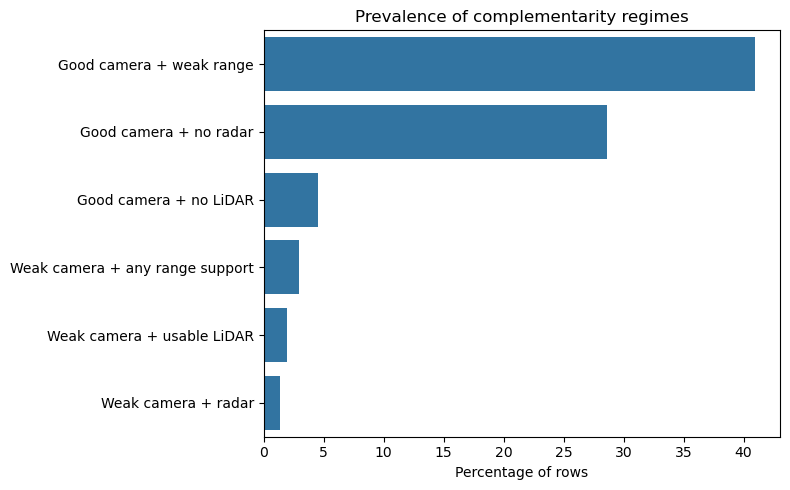

In [114]:
complementarity_flags = [
    "good_camera_no_lidar",
    "good_camera_no_radar",
    "good_camera_weak_range",
    "weak_camera_usable_lidar",
    "weak_camera_has_radar",
    "weak_camera_any_range_support",
]

complementarity_label_map = {
    "good_camera_no_lidar": "Good camera + no LiDAR",
    "good_camera_no_radar": "Good camera + no radar",
    "good_camera_weak_range": "Good camera + weak range",
    "weak_camera_usable_lidar": "Weak camera + usable LiDAR",
    "weak_camera_has_radar": "Weak camera + radar",
    "weak_camera_any_range_support": "Weak camera + any range support",
}

complementarity_summary = (
    eda_df[complementarity_flags]
    .mean()
    .mul(100)
    .rename(index=complementarity_label_map)
    .sort_values(ascending=False)
    .round(2)
)

print("Complementarity regime prevalence (% of rows):")
print(complementarity_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=complementarity_summary.values,
    y=complementarity_summary.index
)
plt.title("Prevalence of complementarity regimes")
plt.xlabel("Percentage of rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Camera compensates weak range support

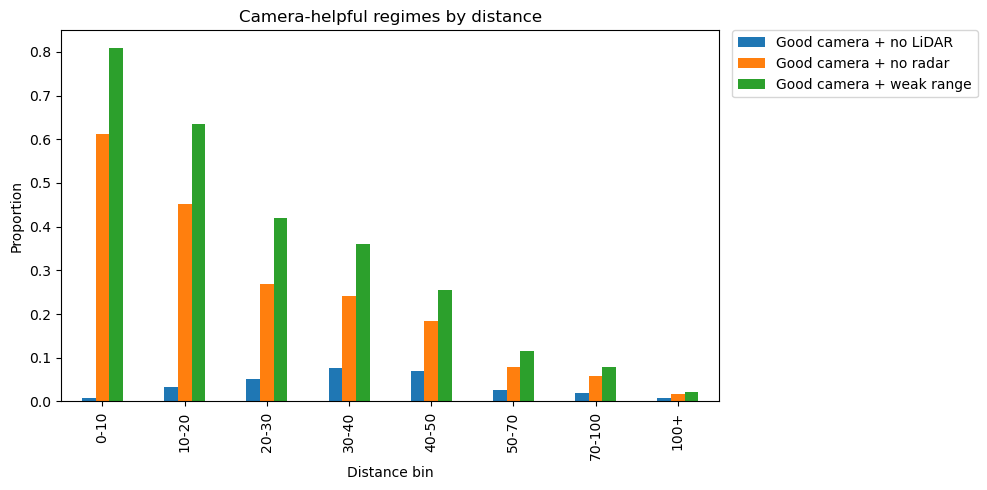

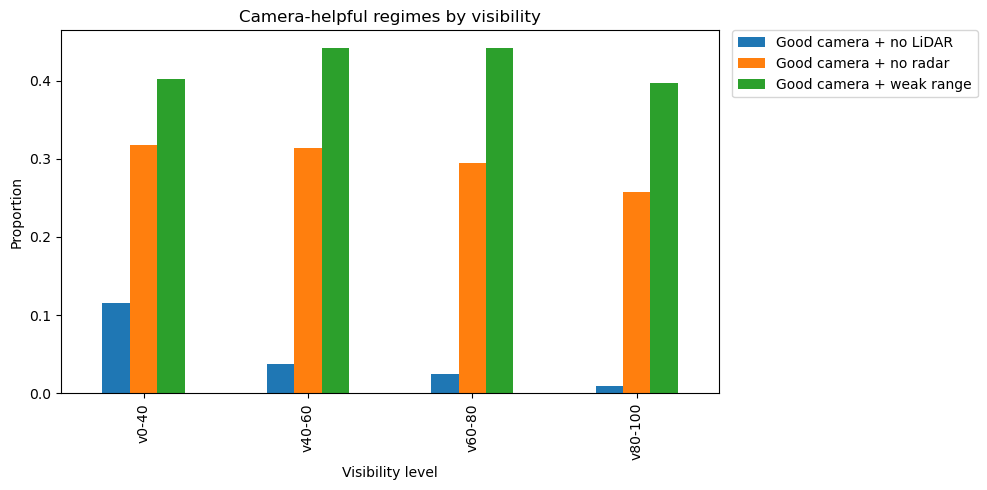

In [115]:
camera_help_flags = [
    "good_camera_no_lidar",
    "good_camera_no_radar",
    "good_camera_weak_range",
]

camera_help_labels = {
    "good_camera_no_lidar": "Good camera + no LiDAR",
    "good_camera_no_radar": "Good camera + no radar",
    "good_camera_weak_range": "Good camera + weak range",
}

# By distance
camera_help_by_distance = summarize_flags_by_group(
    eda_df,
    "distance_bin",
    camera_help_flags
).rename(columns=camera_help_labels)

plot_grouped_flag_rates(
    table=camera_help_by_distance,
    title="Camera-helpful regimes by distance",
    xlabel="Distance bin",
    ylabel="Proportion",
    rot=90
)

# By visibility
camera_help_by_visibility = summarize_flags_by_group(
    eda_df,
    "visibility_level",
    camera_help_flags
).rename(columns=camera_help_labels)

plot_grouped_flag_rates(
    table=camera_help_by_visibility,
    title="Camera-helpful regimes by visibility",
    xlabel="Visibility level",
    ylabel="Proportion",
    rot=90
)

### Range sensing compensates weak camera

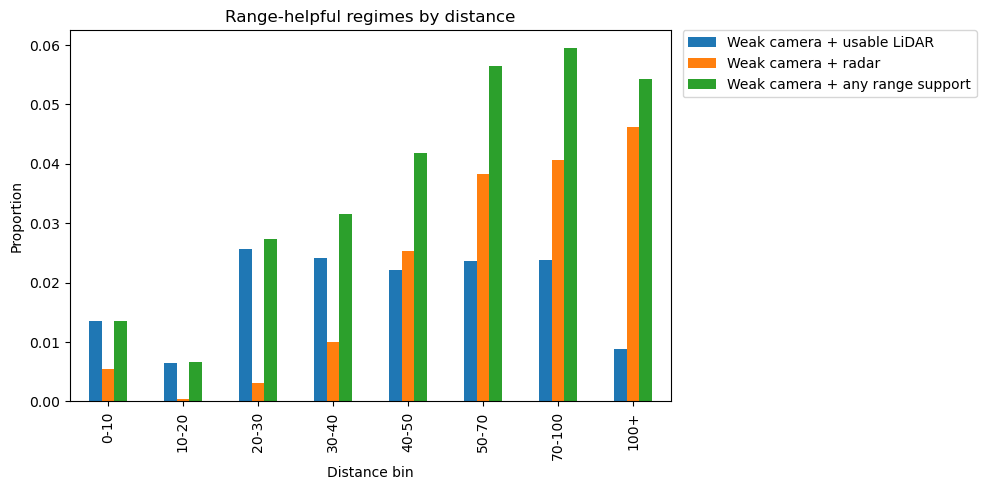

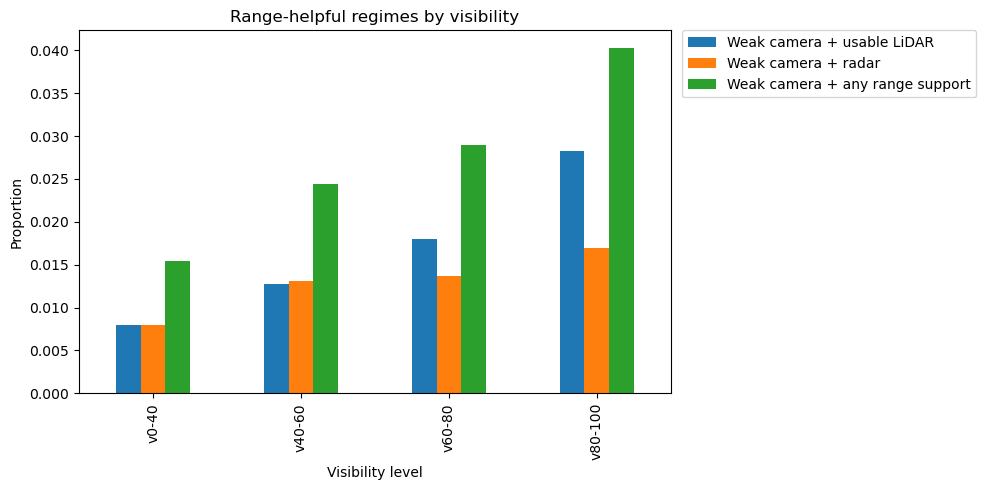

In [116]:
range_help_flags = [
    "weak_camera_usable_lidar",
    "weak_camera_has_radar",
    "weak_camera_any_range_support",
]

range_help_labels = {
    "weak_camera_usable_lidar": "Weak camera + usable LiDAR",
    "weak_camera_has_radar": "Weak camera + radar",
    "weak_camera_any_range_support": "Weak camera + any range support",
}

# By distance
range_help_by_distance = summarize_flags_by_group(
    eda_df,
    "distance_bin",
    range_help_flags
).rename(columns=range_help_labels)

plot_grouped_flag_rates(
    table=range_help_by_distance,
    title="Range-helpful regimes by distance",
    xlabel="Distance bin",
    ylabel="Proportion",
    rot=90
)

# By visibility
range_help_by_visibility = summarize_flags_by_group(
    eda_df,
    "visibility_level",
    range_help_flags
).rename(columns=range_help_labels)

plot_grouped_flag_rates(
    table=range_help_by_visibility,
    title="Range-helpful regimes by visibility",
    xlabel="Visibility level",
    ylabel="Proportion",
    rot=90
)

### category-level views

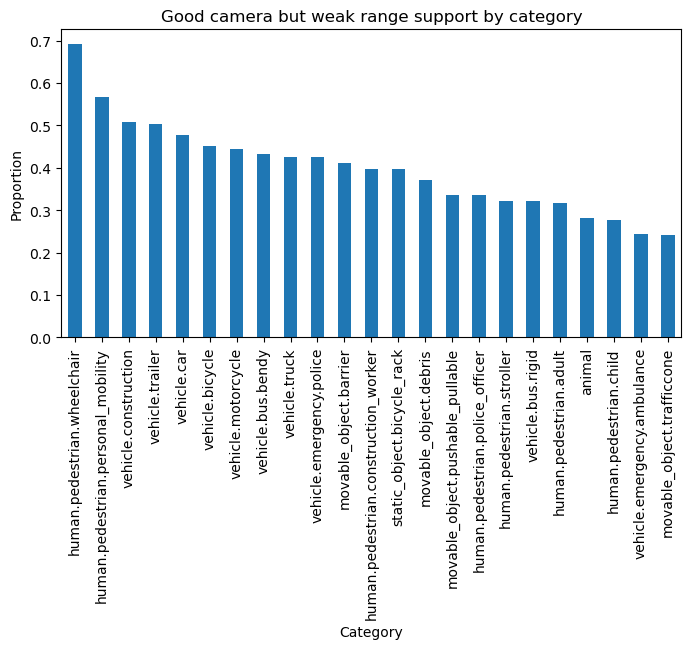

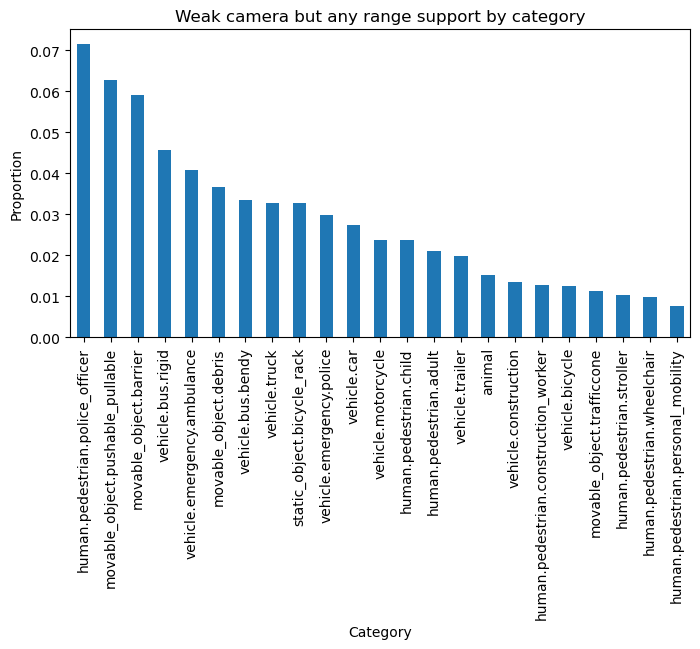

In [117]:
# ------------------------------------------------------------
# 5. Optional category-level views
# Keep only 1-2 compact views to avoid clutter
# ------------------------------------------------------------

# A. Categories where camera is often good while range is weak
cam_help_by_category = plot_flag_by_category(
    df=eda_df,
    flag_col="good_camera_weak_range",
    title="Good camera but weak range support by category",
    ylabel="Proportion",
    ascending=False
)

# B. Categories where camera is weak but at least one range sensor helps
range_help_by_category = plot_flag_by_category(
    df=eda_df,
    flag_col="weak_camera_any_range_support",
    title="Weak camera but any range support by category",
    ylabel="Proportion",
    ascending=False
)




### compact summary tables for reporting

In [118]:
# ------------------------------------------------------------
# 6. Optional compact summary tables for reporting
# ------------------------------------------------------------
print("\nCamera-helpful regimes by distance:")
display(camera_help_by_distance.round(3))

print("\nRange-helpful regimes by distance:")
display(range_help_by_distance.round(3))

print("\nCamera-helpful regimes by visibility:")
display(camera_help_by_visibility.round(3))

print("\nRange-helpful regimes by visibility:")
display(range_help_by_visibility.round(3))


Camera-helpful regimes by distance:


,Good camera + no LiDAR,Good camera + no radar,Good camera + weak range
distance_bin,,,
0-10,0.008,0.612,0.809
10-20,0.033,0.451,0.635
20-30,0.052,0.268,0.421
30-40,0.077,0.242,0.360
40-50,0.069,0.183,0.254
50-70,0.025,0.080,0.115
70-100,0.020,0.057,0.079
100+,0.008,0.018,0.022



Range-helpful regimes by distance:


,Weak camera + usable LiDAR,Weak camera + radar,Weak camera + any range support
distance_bin,,,
0-10,0.014,0.005,0.014
10-20,0.006,0.000,0.007
20-30,0.026,0.003,0.027
30-40,0.024,0.010,0.031
40-50,0.022,0.025,0.042
50-70,0.024,0.038,0.056
70-100,0.024,0.041,0.060
100+,0.009,0.046,0.054



Camera-helpful regimes by visibility:


,Good camera + no LiDAR,Good camera + no radar,Good camera + weak range
visibility_level,,,
v0-40,0.116,0.318,0.402
v40-60,0.038,0.314,0.442
v60-80,0.025,0.295,0.442
v80-100,0.009,0.257,0.398



Range-helpful regimes by visibility:


,Weak camera + usable LiDAR,Weak camera + radar,Weak camera + any range support
visibility_level,,,
v0-40,0.008,0.008,0.015
v40-60,0.013,0.013,0.024
v60-80,0.018,0.014,0.029
v80-100,0.028,0.017,0.040


### Observations

What this section should conclude

This section should answer:

when camera helps weak range sensing
when range sensors help weak camera
whether complementarity is uniform or regime-specific
Example key insights
Example 1

Complementarity is not uniform across the dataset; it appears most strongly in specific distance and visibility regimes.

Example 2

Camera remains helpful in cases where LiDAR or radar support is weak, particularly when visual coverage is still good.

Example 3

Range sensors provide useful compensation when camera support is weak, showing that poor visual conditions do not always imply poor overall support.

Example 4

The strongest justification for fusion is not that all modalities are always useful together, but that different modalities remain informative in different failure regimes.

Example 5

Camera-dominant and range-dominant regimes both exist, which supports an adaptive fusion strategy instead of equal treatment of all modalities.

Strong concluding sentence template

Overall, the data shows clear cross-modal complementarity: camera can compensate for weak range sensing in some regimes, while LiDAR and radar can compensate for weak camera support in others, indicating that fusion value is conditional rather than uniform.

## Easy vs Hard Multimodal Regimes

### Key flags

In [119]:
# Strong across all sensors → easy cases
eda_df["strong_all_modalities"] = (
    eda_df["good_camera_view"] &
    eda_df["usable_lidar_support"] &
    eda_df["usable_radar_support"]
)

# Weak across all sensors → hard cases
eda_df["weak_all_modalities"] = (
    eda_df["weak_camera_view"] &
    ~eda_df["usable_lidar_support"] &
    ~eda_df["usable_radar_support"]
)

# Optional: intermediate cases (very useful)
eda_df["camera_only_strong"] = (
    eda_df["good_camera_view"] &
    ~eda_df["usable_lidar_support"] &
    ~eda_df["usable_radar_support"]
)

eda_df["range_only_strong"] = (
    eda_df["weak_camera_view"] &
    (
        eda_df["usable_lidar_support"] |
        eda_df["usable_radar_support"]
    )
)

### Global prevalence

In [120]:
regime_flags = [
    "strong_all_modalities",
    "weak_all_modalities",
    "camera_only_strong",
    "range_only_strong",
]

regime_labels = {
    "strong_all_modalities": "Strong all modalities",
    "weak_all_modalities": "Weak all modalities",
    "camera_only_strong": "Camera only strong",
    "range_only_strong": "Range only strong",
}

regime_summary = (
    eda_df[regime_flags]
    .mean()
    .mul(100)
    .rename(index=regime_labels)
    .sort_values(ascending=False)
    .round(2)
)

print("Multimodal regime distribution (% of dataset):")
print(regime_summary)

Multimodal regime distribution (% of dataset):
Weak all modalities      22.01
Camera only strong       11.65
Strong all modalities     9.02
Range only strong         2.99
dtype: float64


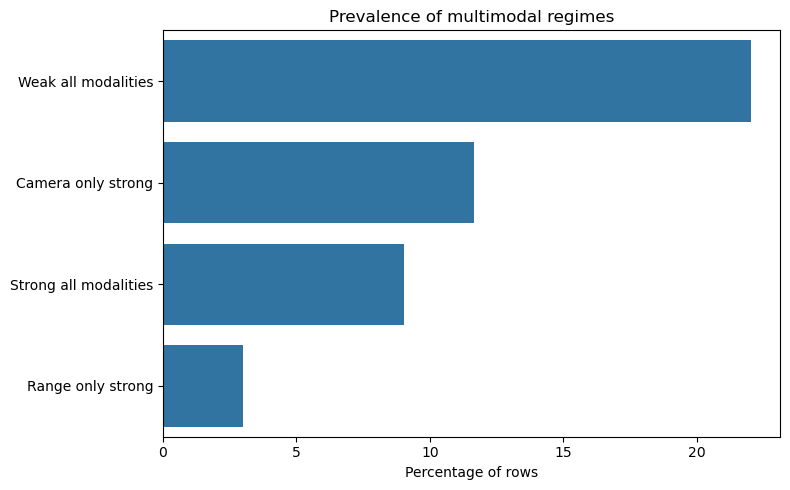

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(
    x=regime_summary.values,
    y=regime_summary.index
)
plt.title("Prevalence of multimodal regimes")
plt.xlabel("Percentage of rows")
plt.ylabel("")
plt.tight_layout()
plt.show()

### By distance

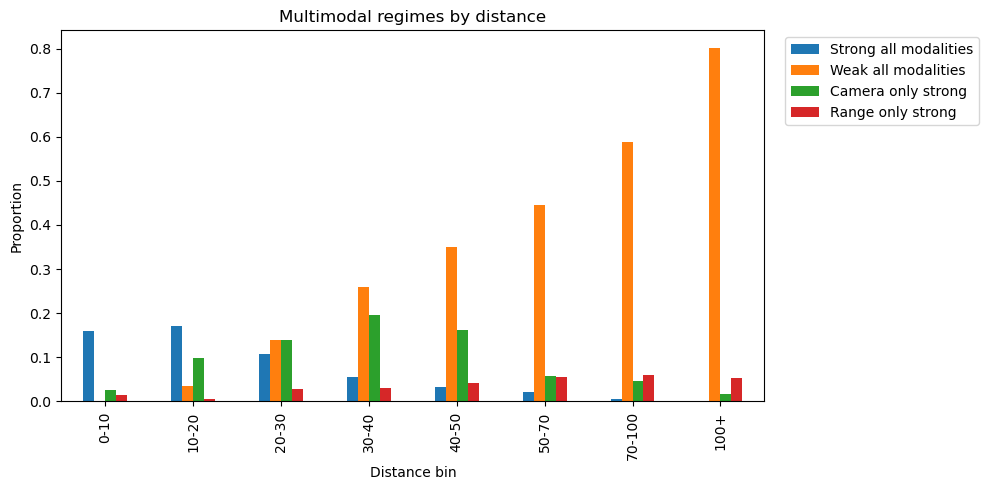

In [122]:
def summarize_flags_by_group(df, group_col, flag_cols):
    return (
        df.groupby(group_col)[flag_cols]
        .mean()
        .sort_index()
    )

regime_by_distance = summarize_flags_by_group(
    eda_df,
    "distance_bin",
    regime_flags
).rename(columns=regime_labels)

regime_by_distance.plot(kind="bar", figsize=(10, 5))
plt.title("Multimodal regimes by distance")
plt.xlabel("Distance bin")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### By visibility

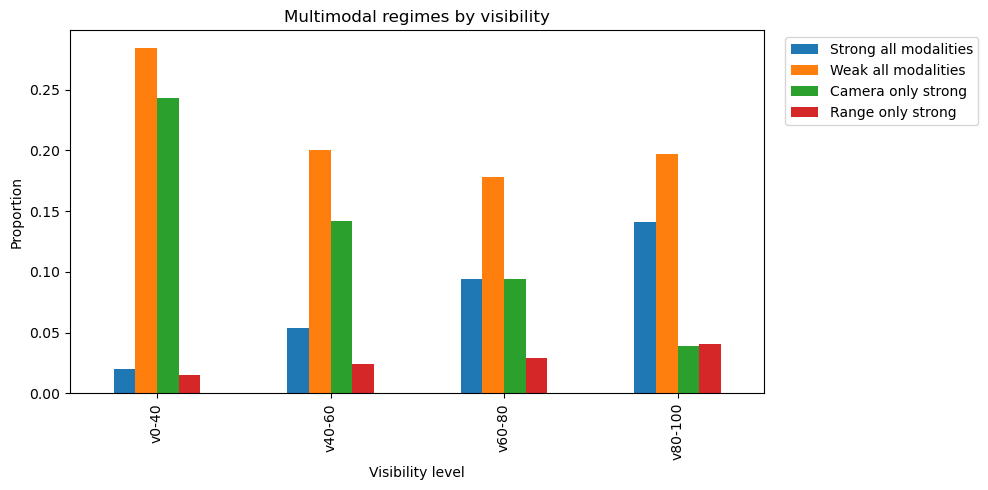

In [123]:
regime_by_visibility = summarize_flags_by_group(
    eda_df,
    "visibility_level",
    regime_flags
).rename(columns=regime_labels)

regime_by_visibility.plot(kind="bar", figsize=(10, 5))
plt.title("Multimodal regimes by visibility")
plt.xlabel("Visibility level")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.legend(
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

### Category

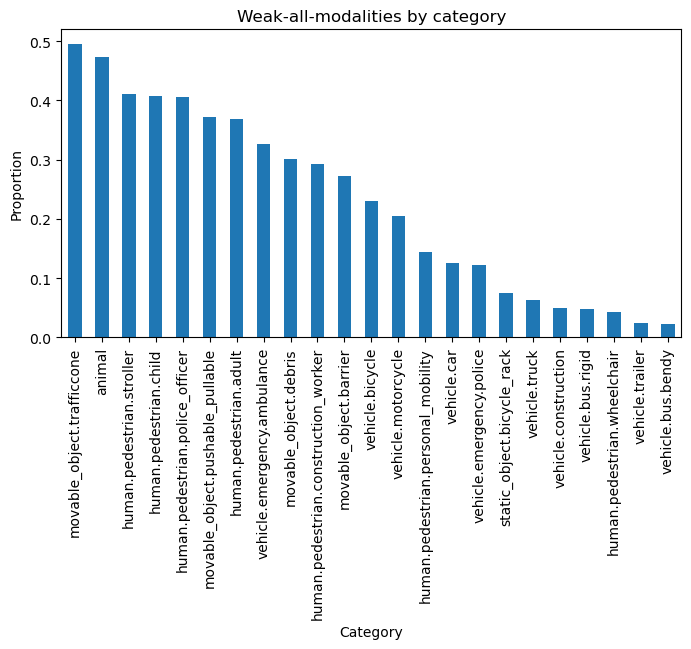

In [124]:
hard_by_category = (
    pd.crosstab(
        index=eda_df["category_name"],
        columns=eda_df["weak_all_modalities"],
        normalize="index",
    )
    .sort_values(by=True, ascending=False)
)

plot_bar_from_table(
    table=hard_by_category,
    column=True,
    title="Weak-all-modalities by category",
    ylabel="Proportion",
    xlabel="Category",
    rot=90
)

**Notes:**

This shows which classes are intrinsically hard even with fusion

### Observations

1. Easy cases
where all sensors are strong
likely close range / good visibility
2. Hard cases
where all sensors are weak
likely far + low visibility
3. Fusion usefulness
fusion helps mostly in intermediate regimes
fusion does NOT solve:
weak_all_modalities cases


Fusion is not universally effective; it is most beneficial in intermediate regimes where at least one modality remains informative, while fully weak regimes remain challenging.


What this section should conclude

This section should answer:

* where all sensors are strong
* where all sensors are weak
* how common easy and hard multimodal regimes are
* what that implies about the limits of fusion


Example key insights

Easy regimes
* A subset of cases is well supported across modalities, meaning they are likely easier and less dependent on sophisticated fusion.
* Strong-all-modality cases likely correspond to favorable distance and visibility conditions.

Hard regimes
* Weak-all-modality cases represent genuinely difficult situations where fusion may still struggle.
* These cases are especially important because they reveal the limits of sensor complementarity.
* If a meaningful share of the dataset falls into weak-all-modalities regimes, then improved fusion alone may not fully solve performance gaps.

Intermediate regimes
* Fusion is likely most valuable in intermediate support regimes, where at least one modality remains informative while another is weak.
* This suggests the best use of fusion is not in easiest cases or hardest cases, but in partially supported ones.


Strong concluding sentence template

Overall, multimodal support is polarized into easy, well-supported cases and hard, weakly supported cases, with fusion appearing most useful in intermediate regimes where at least one modality can compensate for another.

## Regime analysis: where does difficulty come from?

* How does detection difficulty change with distance?
* How does difficulty change with visibility / occlusion?
* How does difficulty change with object size or projected pixel area?
* Which combinations are especially hard: far + small, small + low visibility, far + low LiDAR support?
* Are there natural operating regimes in the data that should be analyzed separately?

# Machine learning

## Machine Learning Research Question
In this Jupyter notebook, I build a supervised 3D object detection pipeline on nuScenes by preparing inputs and targets directly from the official tables. For each sample (one timestamp in the sample table), I assemble the model input by collecting the linked sensor records in sample_data: the LiDAR point cloud file (LIDAR_TOP), the six camera image files (CAM_), and optionally the radar point cloud files (RADAR_). I use calibrated_sensor and ego_pose to transform all sensor measurements into a consistent coordinate frame (ego or global) and to align modalities spatially and temporally. I prepare the ground-truth output for each sample from sample_annotation by extracting category_name and the 3D bounding box parameters (translation, size, rotation) and the object velocity, forming a per-sample set of labeled 3D boxes. With these prepared inputs and outputs, I run a controlled ablation where the only change is which sample_data modalities are included (LiDAR-only, camera+LiDAR, camera+LiDAR+radar) and evaluate each variant using the official nuScenes metrics NDS, mAP, and AVE, followed by a short error breakdown by object class and distance.

## Planned Models and Rationale

## Detailed Machine Learning Strategy